# Sentiment Analysis NLP: Classifying Movie Reviews with Machine Learning

## Business Context

This project builds and evaluates NLP classification models to predict whether movie reviews express positive or negative sentiment.

The goal is not only to classify text, but also to demonstrate a complete NLP workflow: text cleaning, TF-IDF vectorization, model comparison, cross-validation, final test evaluation, token interpretation, and error analysis.

## Main Questions

1. Is the sentiment dataset balanced and reliable?
2. What preprocessing is required for raw review text?
3. How strong is a majority-class baseline?
4. Which TF-IDF model performs best?
5. Does cross-validation confirm the model choice?
6. How well does the selected model generalize to the held-out test set?
7. Which tokens are most associated with positive and negative sentiment?
8. Where does the model fail?

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:,.4f}".format)

In [2]:
clean_data = pd.read_csv(PROCESSED_DATA_DIR / "imdb_reviews_clean.csv")
train_data = pd.read_csv(PROCESSED_DATA_DIR / "train_reviews.csv")
validation_data = pd.read_csv(PROCESSED_DATA_DIR / "validation_reviews.csv")
test_data = pd.read_csv(PROCESSED_DATA_DIR / "test_reviews.csv")

model_metrics = pd.read_csv(REPORTS_DIR / "model_metrics.csv")
cv_summary = pd.read_csv(REPORTS_DIR / "cross_validation_summary.csv")
final_test_metrics = pd.read_csv(REPORTS_DIR / "final_test_metrics.csv")
final_classification_report = pd.read_csv(REPORTS_DIR / "final_classification_report.csv")
final_confusion_matrix = pd.read_csv(REPORTS_DIR / "final_confusion_matrix.csv", index_col=0)

top_positive_tokens = pd.read_csv(REPORTS_DIR / "top_positive_tokens.csv")
top_negative_tokens = pd.read_csv(REPORTS_DIR / "top_negative_tokens.csv")
error_analysis = pd.read_csv(REPORTS_DIR / "error_analysis.csv")

clean_data.shape

(49582, 7)

In [3]:
dataset_summary = pd.DataFrame(
    [
        {
            "dataset": "clean_data",
            "rows": len(clean_data),
            "positive_share": clean_data["sentiment_label"].mean(),
            "negative_share": 1 - clean_data["sentiment_label"].mean(),
            "mean_clean_word_count": clean_data["clean_word_count"].mean(),
            "median_clean_word_count": clean_data["clean_word_count"].median(),
        },
        {
            "dataset": "train",
            "rows": len(train_data),
            "positive_share": train_data["sentiment_label"].mean(),
            "negative_share": 1 - train_data["sentiment_label"].mean(),
            "mean_clean_word_count": train_data["clean_word_count"].mean(),
            "median_clean_word_count": train_data["clean_word_count"].median(),
        },
        {
            "dataset": "validation",
            "rows": len(validation_data),
            "positive_share": validation_data["sentiment_label"].mean(),
            "negative_share": 1 - validation_data["sentiment_label"].mean(),
            "mean_clean_word_count": validation_data["clean_word_count"].mean(),
            "median_clean_word_count": validation_data["clean_word_count"].median(),
        },
        {
            "dataset": "test",
            "rows": len(test_data),
            "positive_share": test_data["sentiment_label"].mean(),
            "negative_share": 1 - test_data["sentiment_label"].mean(),
            "mean_clean_word_count": test_data["clean_word_count"].mean(),
            "median_clean_word_count": test_data["clean_word_count"].median(),
        },
    ]
)

dataset_summary

,dataset,rows,positive_share,negative_share,mean_clean_word_count,median_clean_word_count
0,clean_data,49582,0.5019,0.4981,229.9423,172.0000
1,train,34706,0.5019,0.4981,230.4575,173.0000
2,validation,7438,0.5019,0.4981,230.4610,172.0000
3,test,7438,0.5019,0.4981,227.0196,170.0000


## Dataset Quality

The raw dataset originally contained 50,000 reviews.

During preprocessing, 418 duplicate review texts were removed before splitting the data. This prevents duplicate reviews from leaking across train, validation, and test splits.

After deduplication, the clean dataset contains 49,582 reviews.

The sentiment distribution remains almost perfectly balanced, with approximately 50.19% positive and 49.81% negative reviews.

In [4]:
clean_data[["raw_character_length", "clean_character_length", "clean_word_count"]].describe()

,raw_character_length,clean_character_length,clean_word_count
count,"49,582.0000","49,582.0000","49,582.0000"
mean,"1,310.5682","1,250.1765",229.9423
std,990.7622,946.2205,170.3698
min,32.0000,30.0000,6.0000
25%,699.0000,669.0000,126.0000
50%,971.0000,927.0000,172.0000
75%,"1,592.0000","1,516.0000",279.0000
max,"13,704.0000","13,317.0000","2,462.0000"


## Text Length

The reviews vary substantially in length.

The median clean review has around 172 words, while the longest clean review has more than 2,400 words.

This variability matters because very short reviews may lack context, while very long reviews can contain mixed opinions.

In [5]:
model_metrics.sort_values(["f1", "roc_auc"], ascending=False)

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,logistic_regression_tfidf,0.9013,0.8892,0.9178,0.9032,0.9637,0.9633
1,linear_svm_tfidf,0.9010,0.8959,0.9084,0.9021,0.9640,0.9630
2,naive_bayes_tfidf,0.8778,0.8698,0.8896,0.8796,0.9466,0.9455
3,random_forest_tfidf,0.8477,0.8239,0.8859,0.8537,0.9268,0.9247
4,baseline_most_frequent,0.5019,0.5019,1.0000,0.6683,0.5000,0.5019


In [6]:
cv_summary.sort_values(["f1_mean", "roc_auc_mean"], ascending=False)

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
0,linear_svm_tfidf,0.8955,0.0017,0.8898,0.0032,0.9036,0.0011,0.8966,0.0015,0.9608,0.0011,0.9594,0.0016
1,logistic_regression_tfidf,0.8946,0.0022,0.8841,0.0031,0.9093,0.0026,0.8965,0.0022,0.9605,0.0014,0.9596,0.0020
2,naive_bayes_tfidf,0.8738,0.0008,0.8683,0.0021,0.8824,0.0029,0.8753,0.0009,0.9456,0.0008,0.9448,0.0005
3,random_forest_tfidf,0.8432,0.0022,0.8222,0.0005,0.8771,0.0048,0.8488,0.0025,0.9237,0.0014,0.9213,0.0026
4,baseline_most_frequent,0.5019,0.0000,0.5019,0.0000,1.0000,0.0000,0.6683,0.0000,0.5000,0.0000,0.5019,0.0000


## Cross-Validation Results

Cross-validation changes the final model decision.

Although Logistic Regression slightly wins on the single validation split, Linear SVM has the best mean F1-score under cross-validation.

The difference between Linear SVM and Logistic Regression is small, but model selection should rely on validation evidence before looking at the test set.

For this reason, Linear SVM is selected as the final model.

In [7]:
final_test_metrics.sort_values(["f1", "roc_auc"], ascending=False)

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,logistic_regression_tfidf,0.9000,0.8893,0.9145,0.9017,0.9650,0.9649
1,linear_svm_tfidf,0.9000,0.8963,0.9054,0.9009,0.9642,0.9637
2,naive_bayes_tfidf,0.8790,0.8766,0.8832,0.8799,0.9495,0.9479
3,random_forest_tfidf,0.8463,0.8209,0.8875,0.8529,0.9277,0.9258
4,baseline_most_frequent,0.5019,0.5019,1.0000,0.6683,0.5000,0.5019


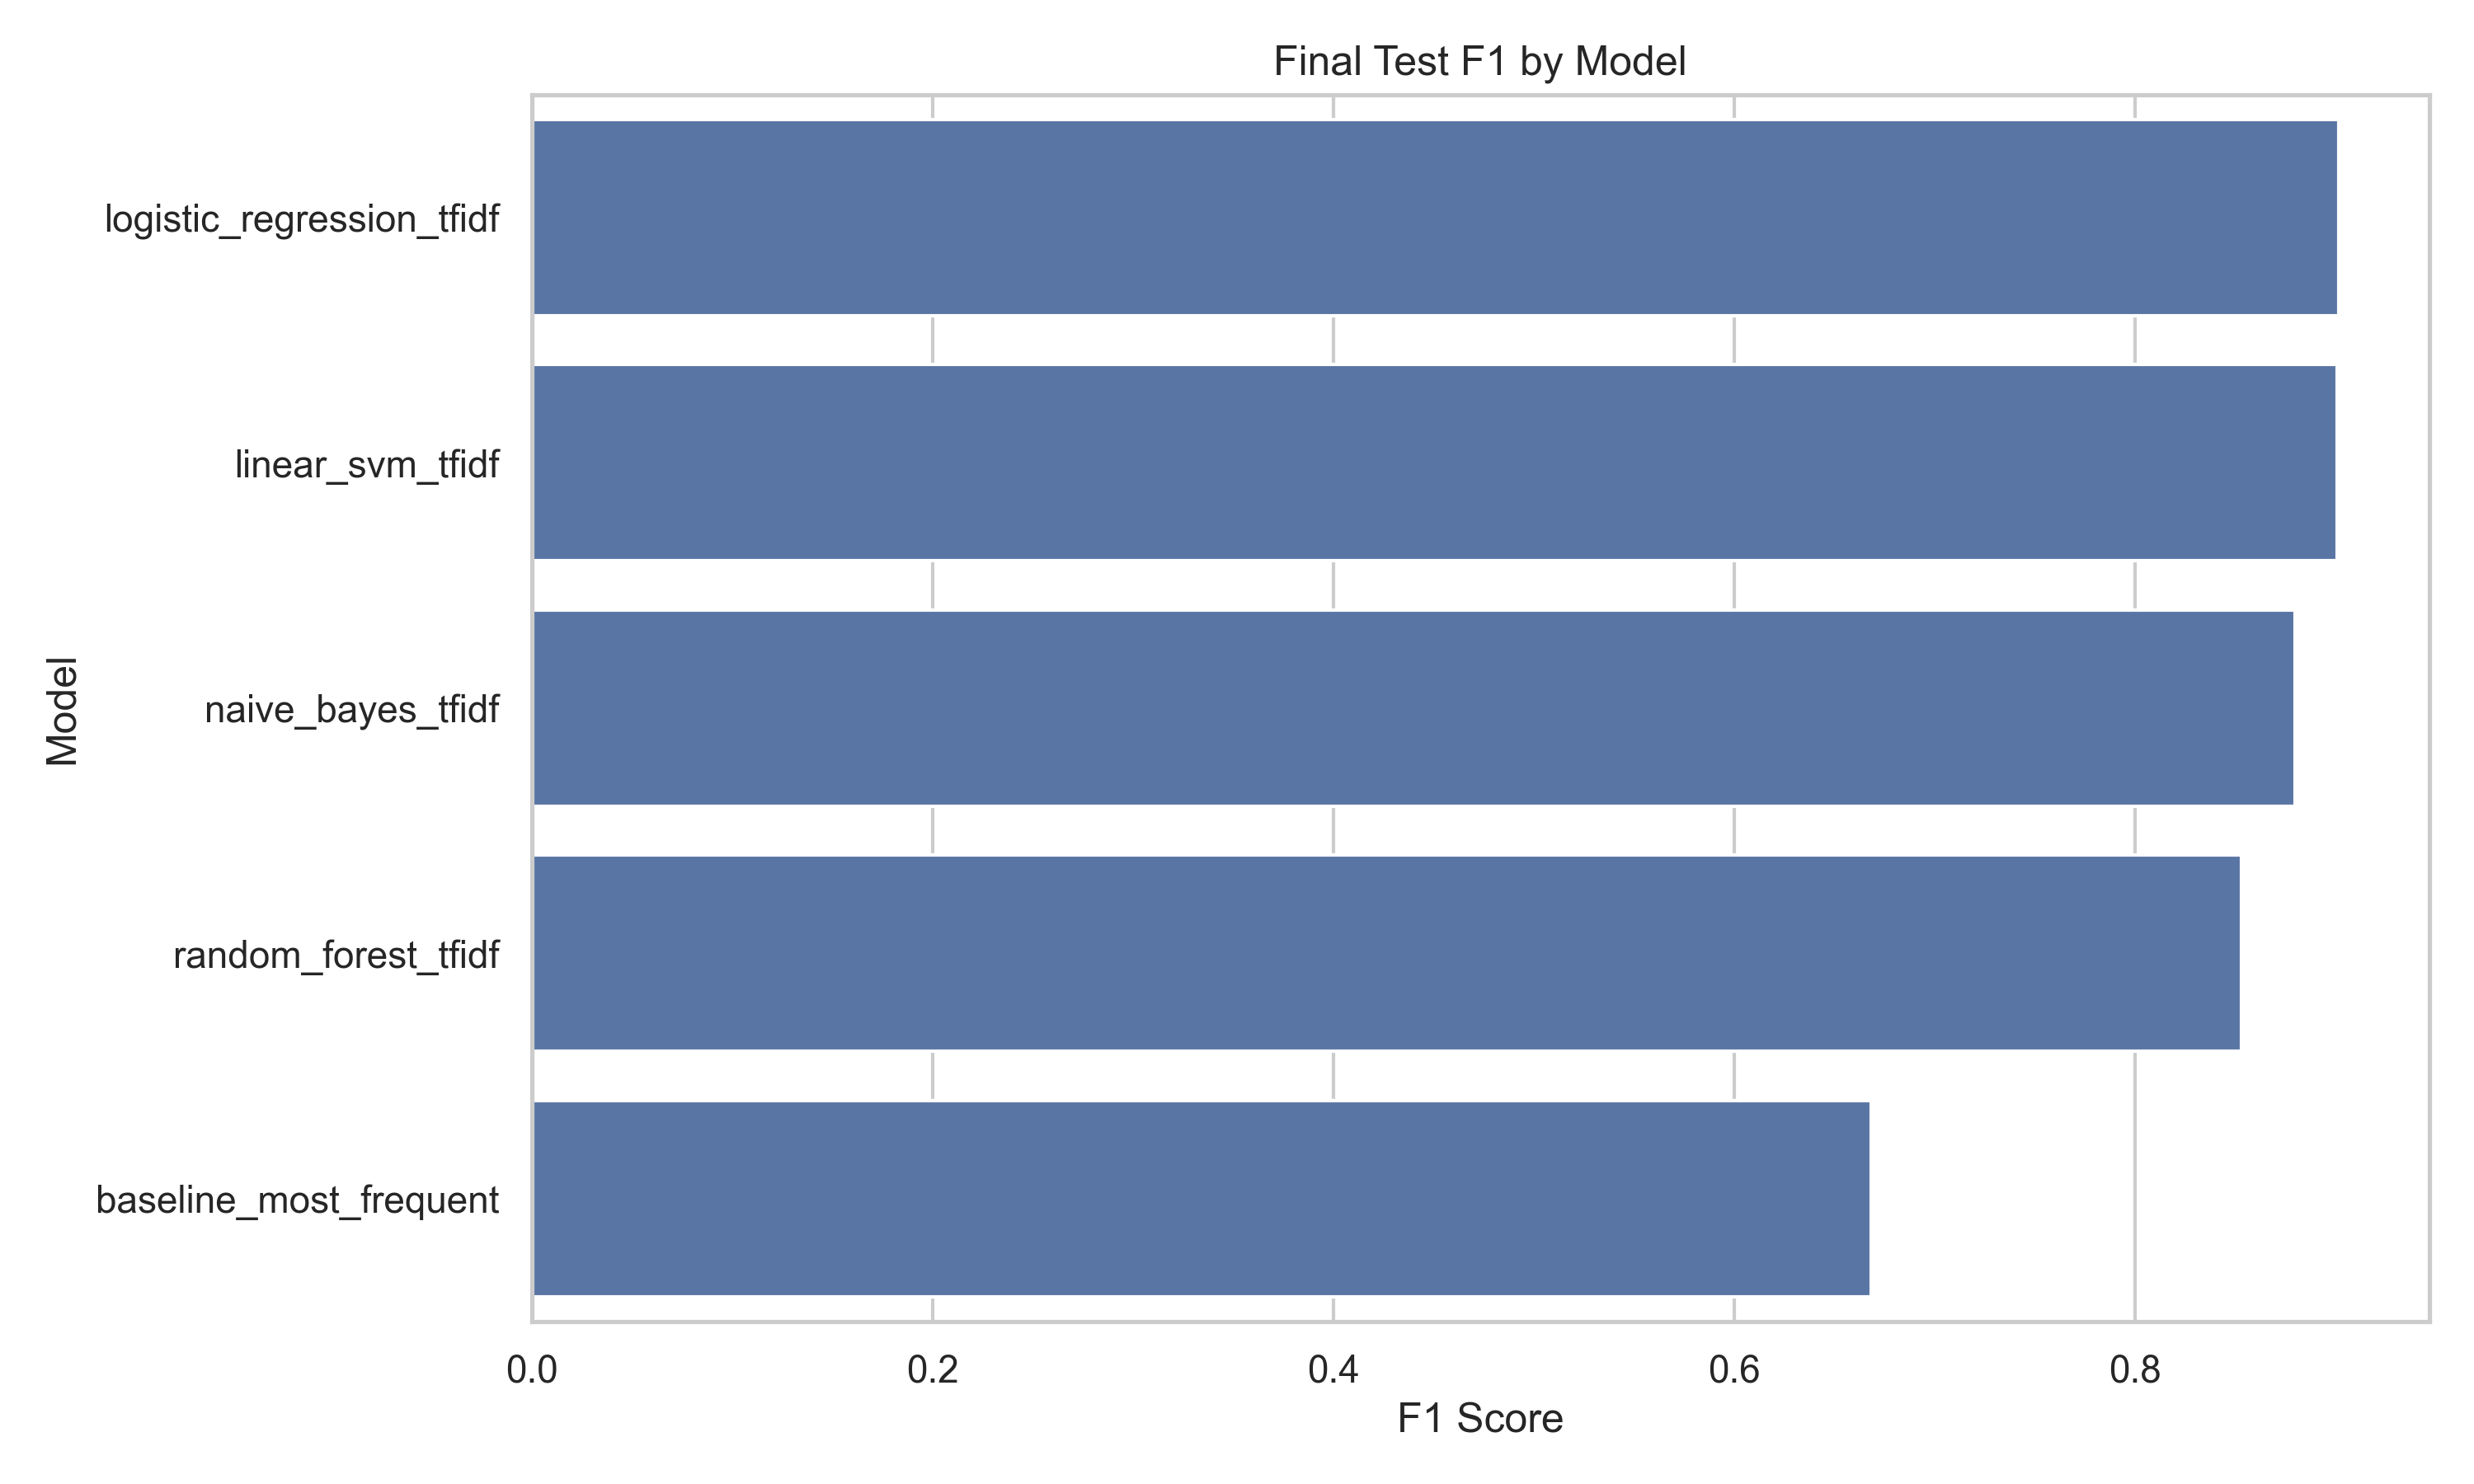

In [8]:
display(Image(filename=FIGURES_DIR / "final_test_f1_by_model.png"))

## Final Test Evaluation

The final selected model is Linear SVM with TF-IDF features.

On the held-out test set, Linear SVM achieves:

- Accuracy: 0.9000
- Precision: 0.8963
- Recall: 0.9054
- F1-score: 0.9009
- ROC-AUC: 0.9642
- Average Precision: 0.9637

Logistic Regression performs marginally better on the test split, but it was not selected as the final model because test results should not be used for model selection.

In [9]:
final_classification_report

,Unnamed: 0,precision,recall,f1-score,support
0,negative,0.9037,0.8945,0.8991,"3,705.0000"
1,positive,0.8963,0.9054,0.9009,"3,733.0000"
2,accuracy,0.9000,0.9000,0.9000,0.9000
3,macro avg,0.9000,0.9000,0.9000,"7,438.0000"
4,weighted avg,0.9000,0.9000,0.9000,"7,438.0000"


In [10]:
final_confusion_matrix

,Predicted Negative,Predicted Positive
Actual Negative,3314,391
Actual Positive,353,3380


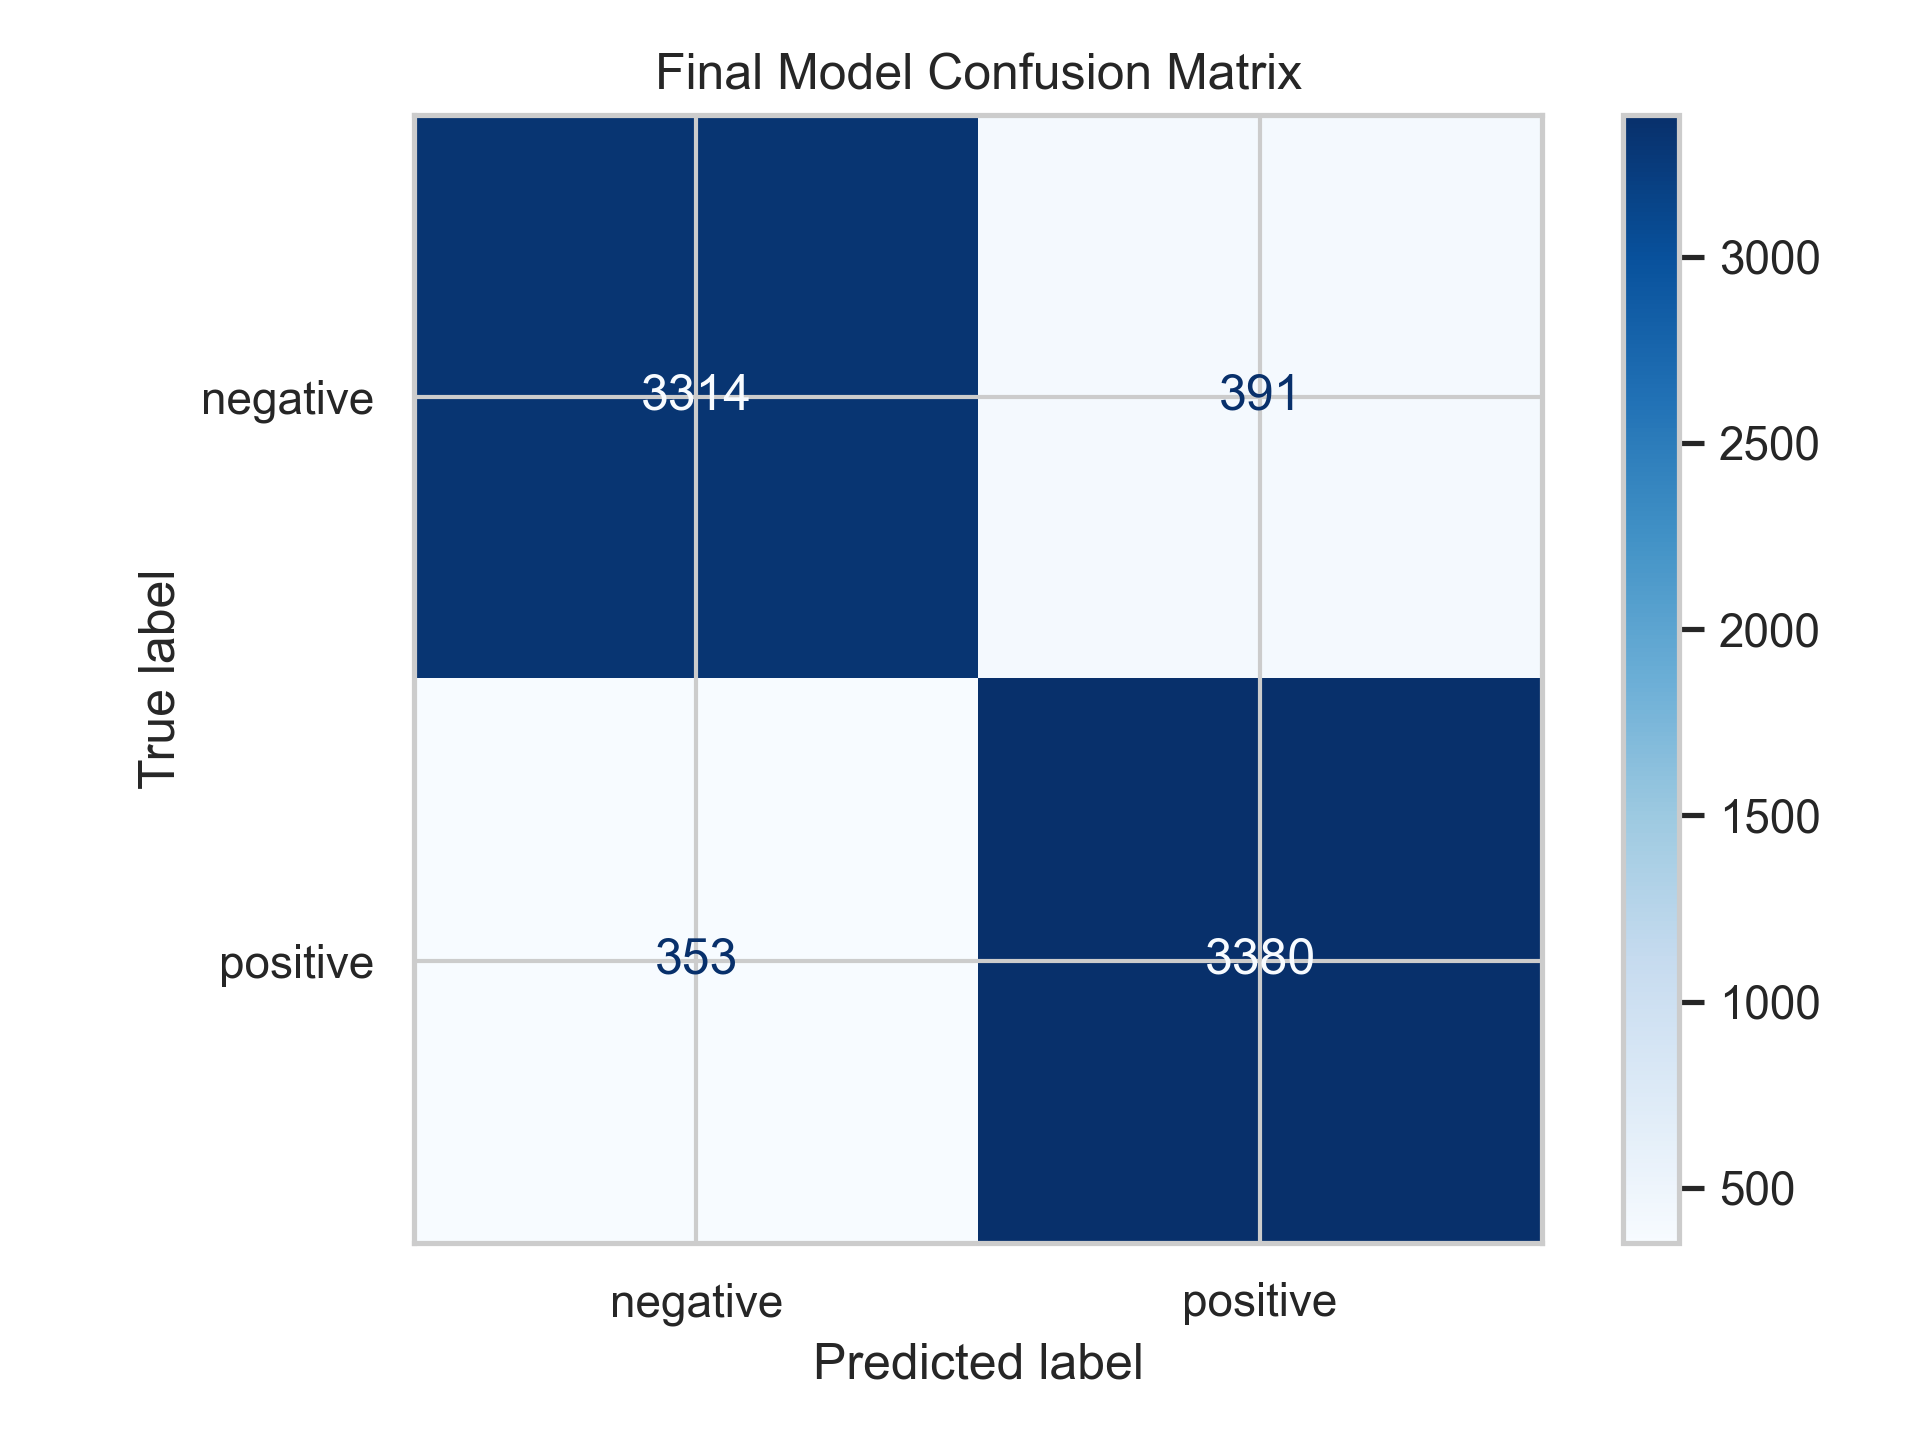

In [11]:
display(Image(filename=FIGURES_DIR / "final_confusion_matrix.png"))

## Confusion Matrix

The final Linear SVM model correctly classifies 6,694 out of 7,438 test reviews.

The model makes:

- 391 false positives,
- 353 false negatives.

False positives are negative reviews predicted as positive.
False negatives are positive reviews predicted as negative.

The error distribution is relatively balanced, which is expected given the balanced dataset.

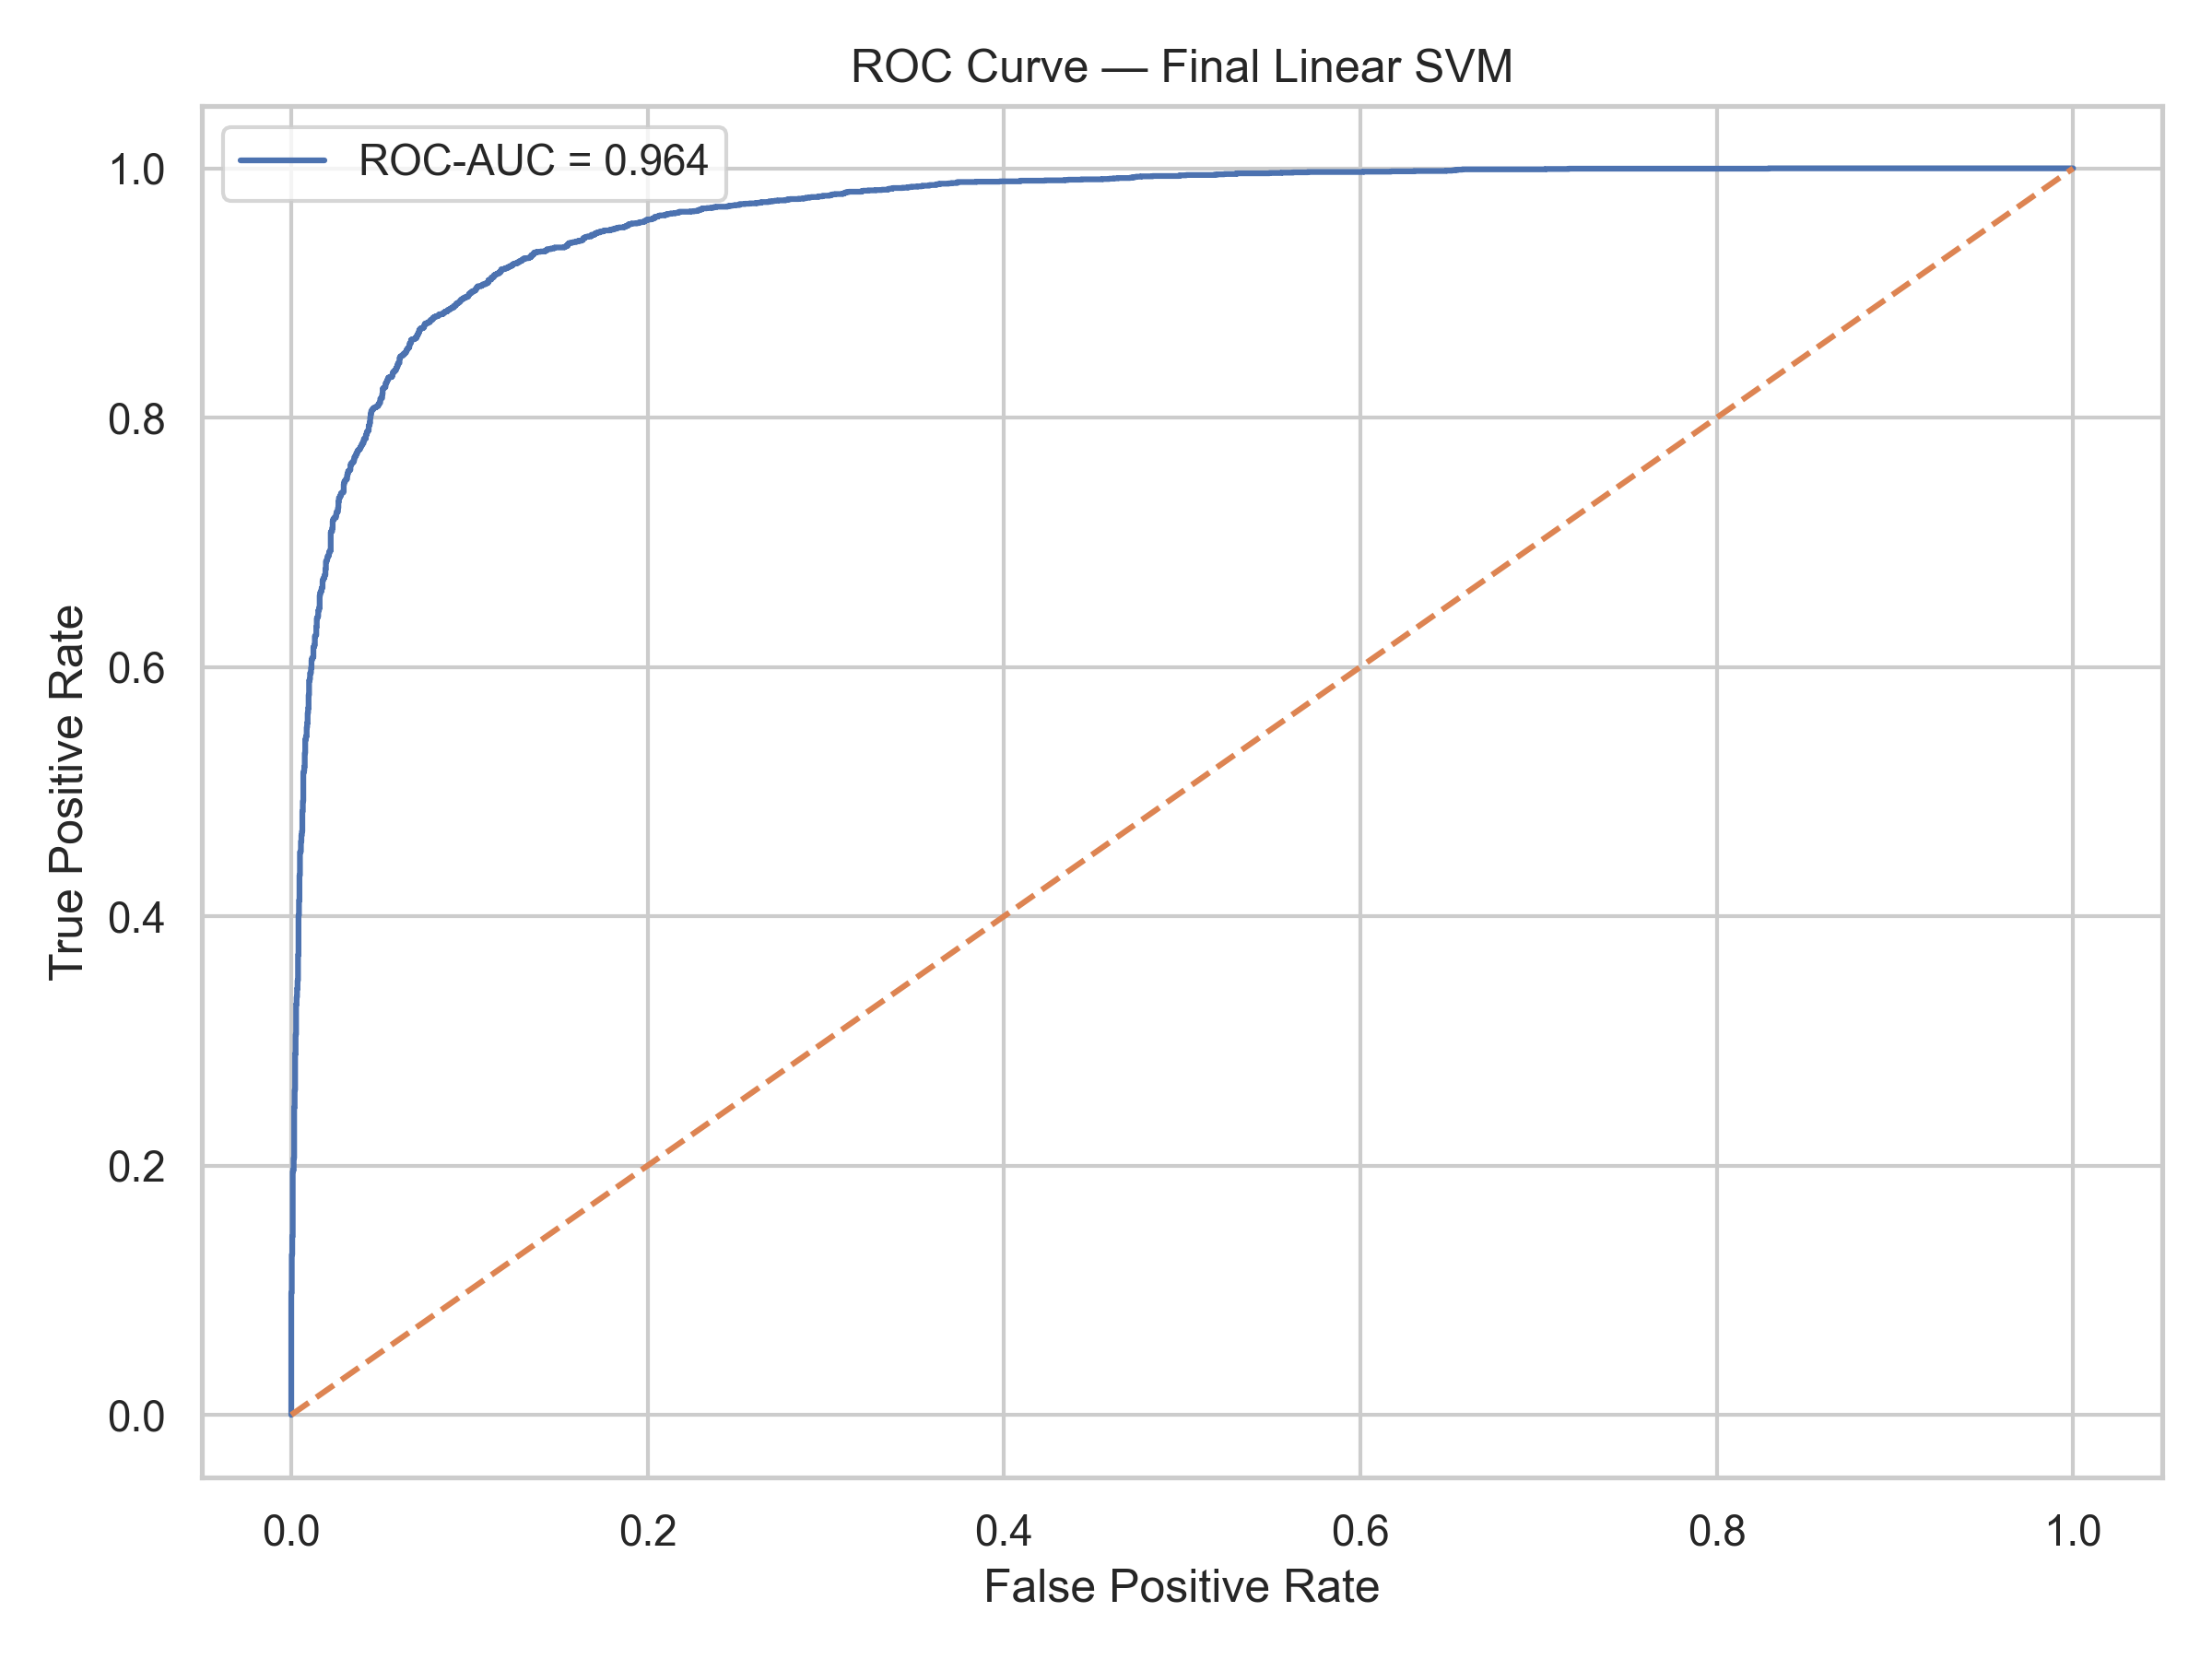

In [12]:
display(Image(filename=FIGURES_DIR / "final_roc_curve.png"))

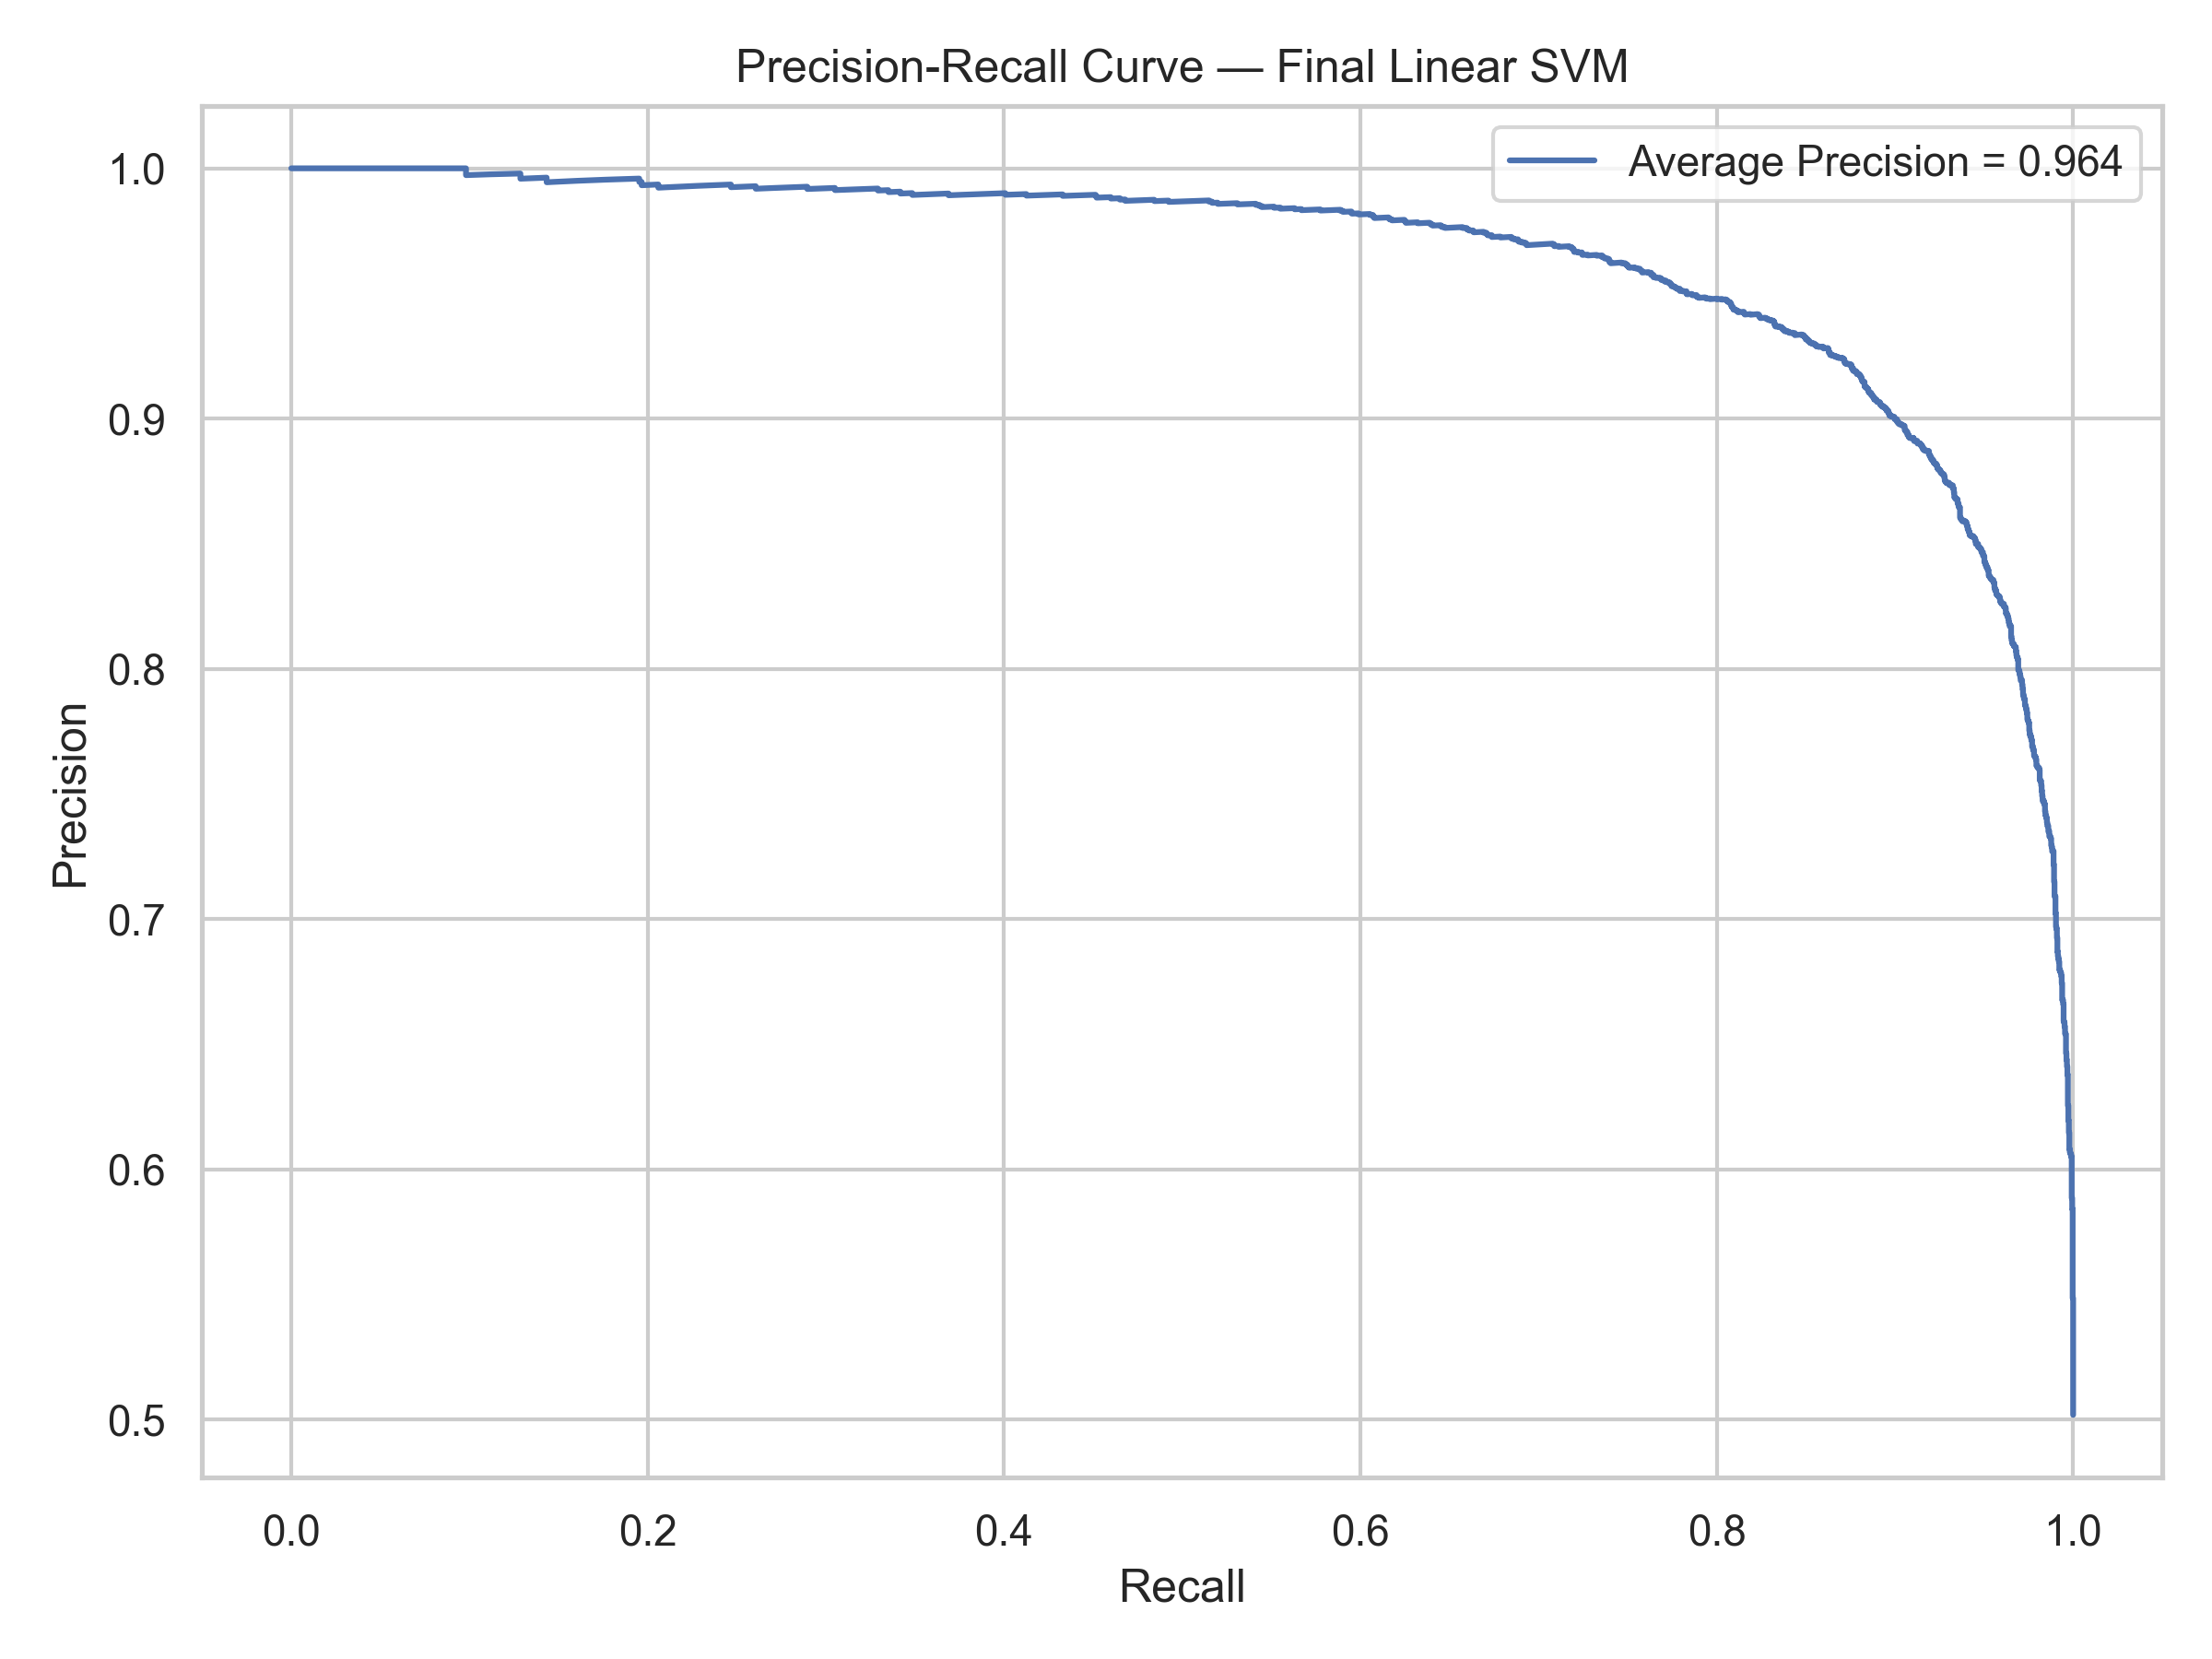

In [13]:
display(Image(filename=FIGURES_DIR / "final_precision_recall_curve.png"))

## Ranking Performance

The final model has strong ranking performance.

ROC-AUC and Average Precision are both above 0.96, which means the model separates positive and negative sentiment well across decision thresholds.

This is stronger evidence than accuracy alone.

In [14]:
top_positive_tokens[["token", "coefficient"]].head(20)

,token,coefficient
0,excellent,3.5431
1,great,3.4547
2,perfect,3.3100
3,best,2.9010
4,amazing,2.5747
5,refreshing,2.5439
6,brilliant,2.5244
7,wonderful,2.4867
8,enjoyable,2.4705
9,favorite,2.4030


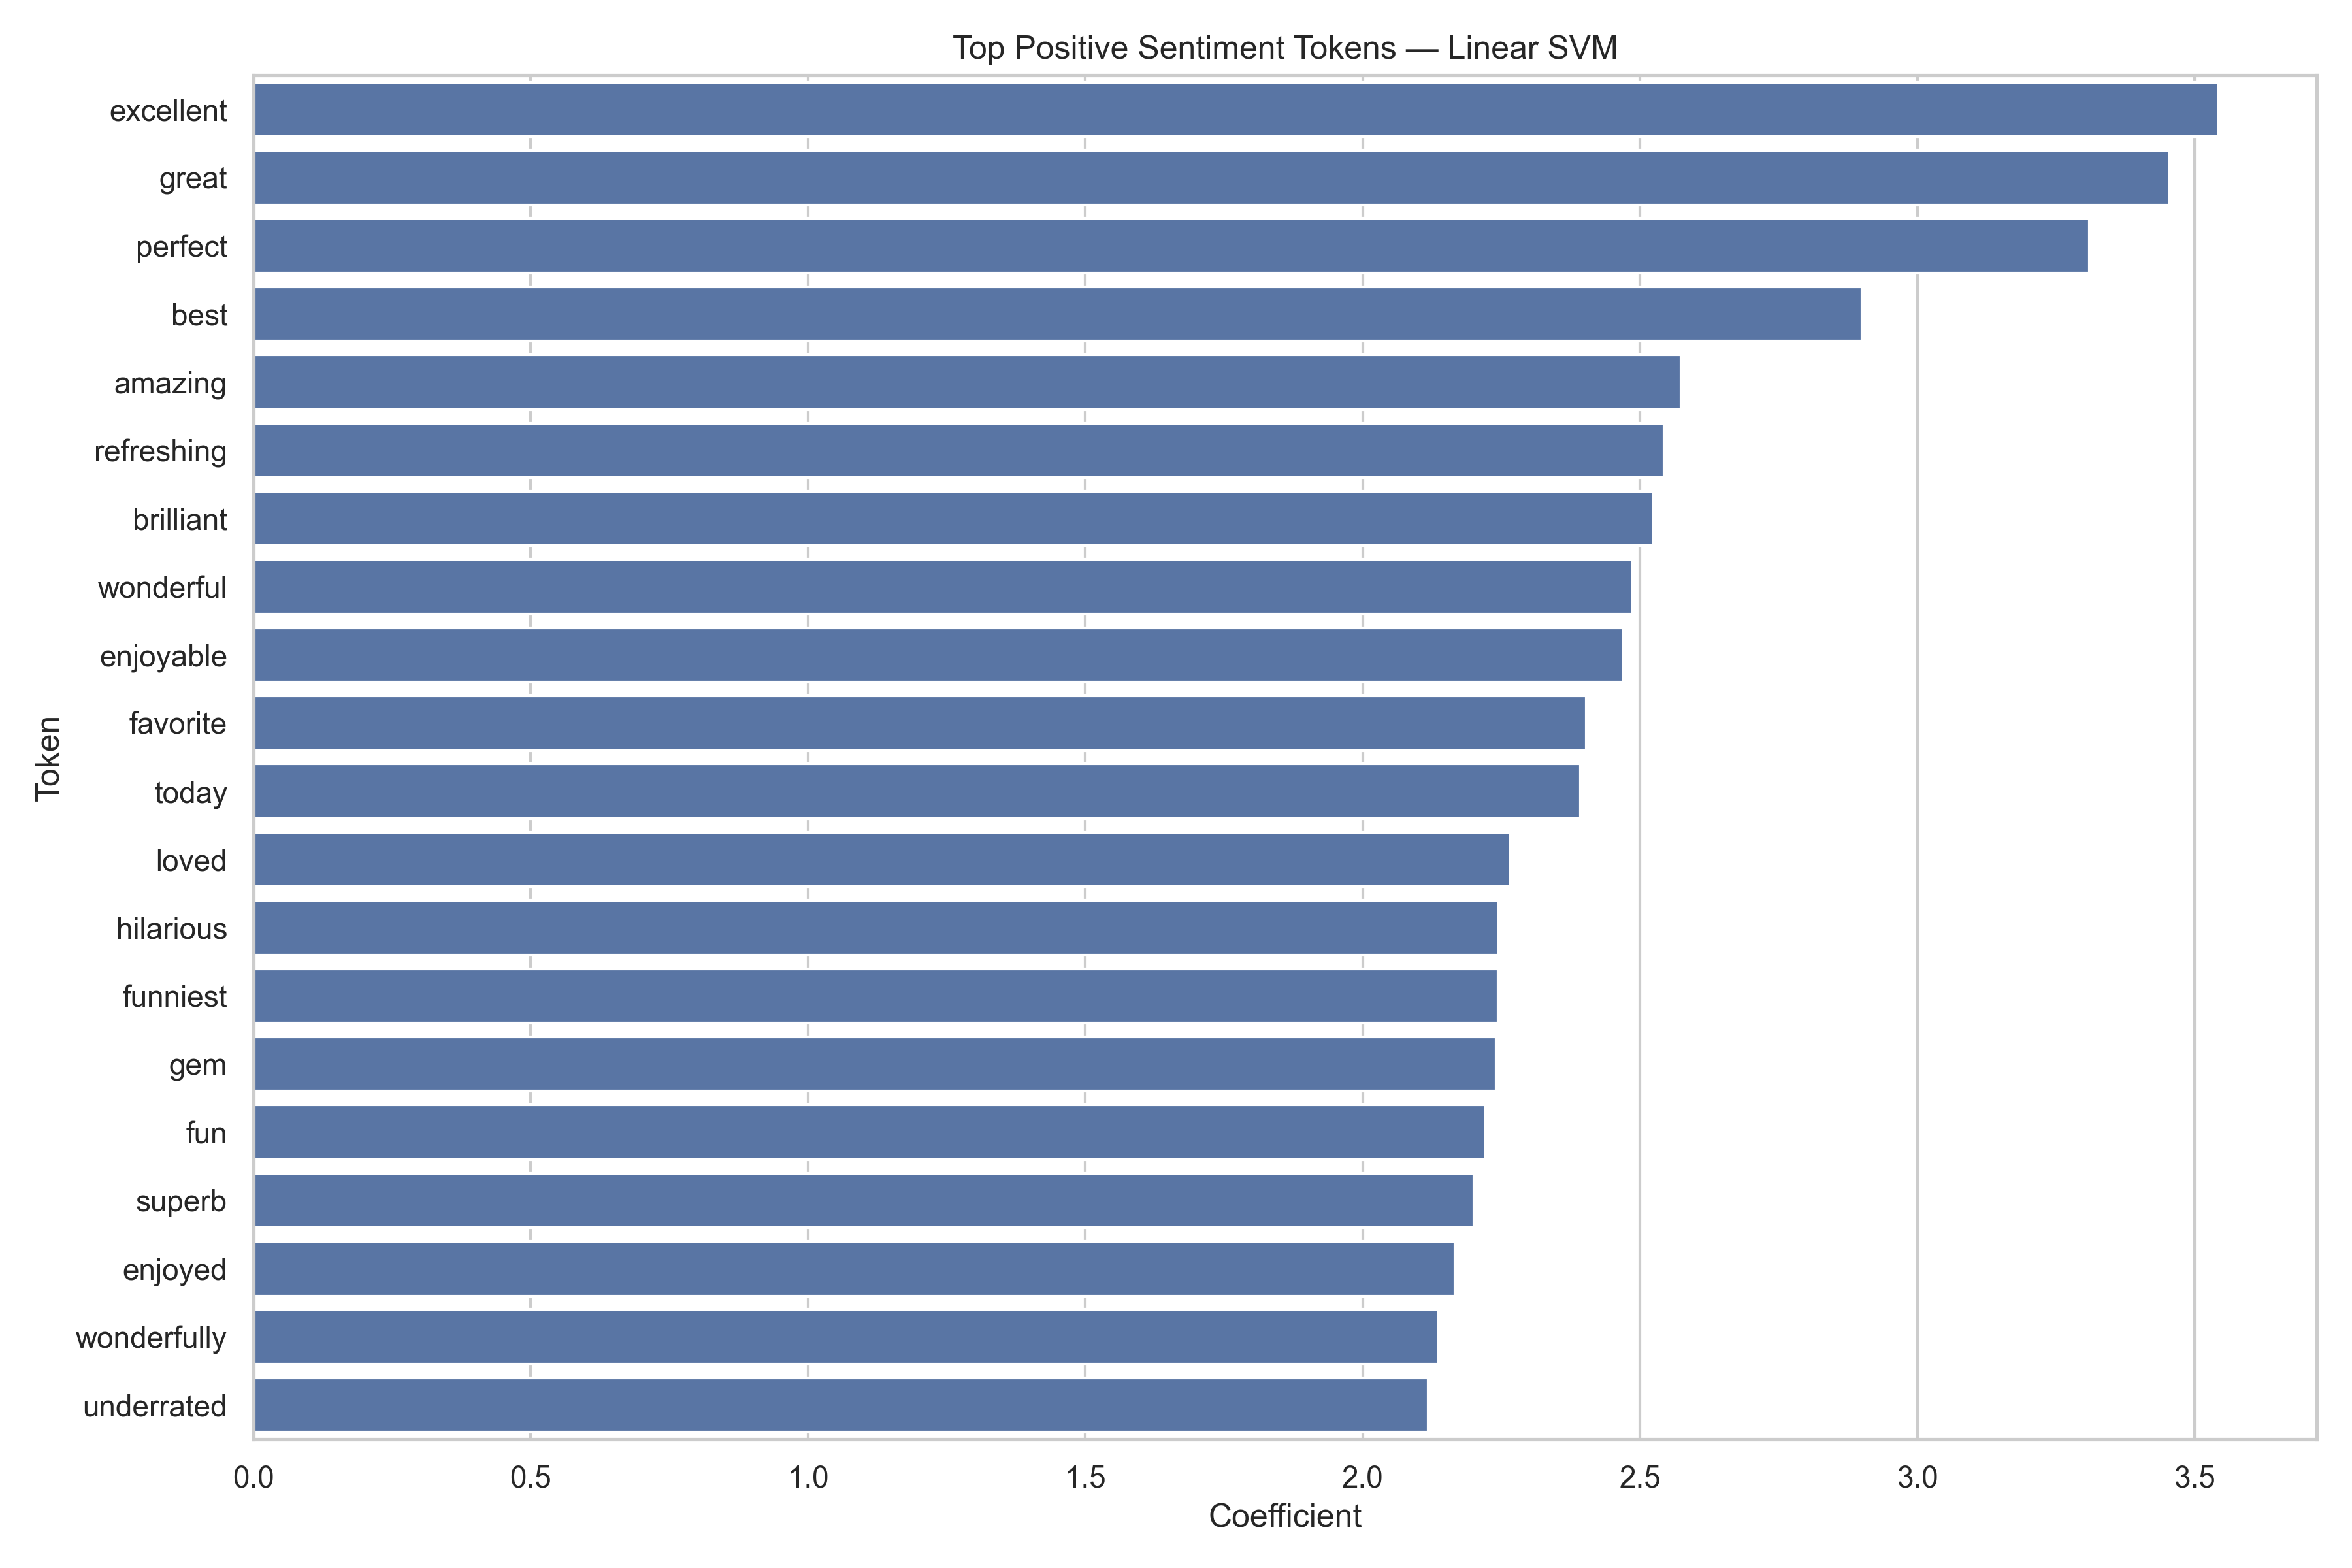

In [15]:
display(Image(filename=FIGURES_DIR / "top_positive_sentiment_tokens.png"))

## Positive Sentiment Signals

The strongest positive sentiment tokens include words such as excellent, great, perfect, amazing, brilliant, wonderful, enjoyable, loved, hilarious, and superb.

These tokens align with intuitive positive sentiment language.

However, coefficients should be interpreted as statistical associations in the TF-IDF feature space, not as causal explanations.

In [16]:
top_negative_tokens[["token", "coefficient"]].head(20)

,token,coefficient
0,worst,-4.9517
1,awful,-4.2430
2,waste,-3.7337
3,bad,-3.7067
4,boring,-3.4998
5,disappointment,-3.4583
6,terrible,-3.1938
7,fails,-3.1621
8,forgettable,-3.0006
9,mediocre,-2.9525


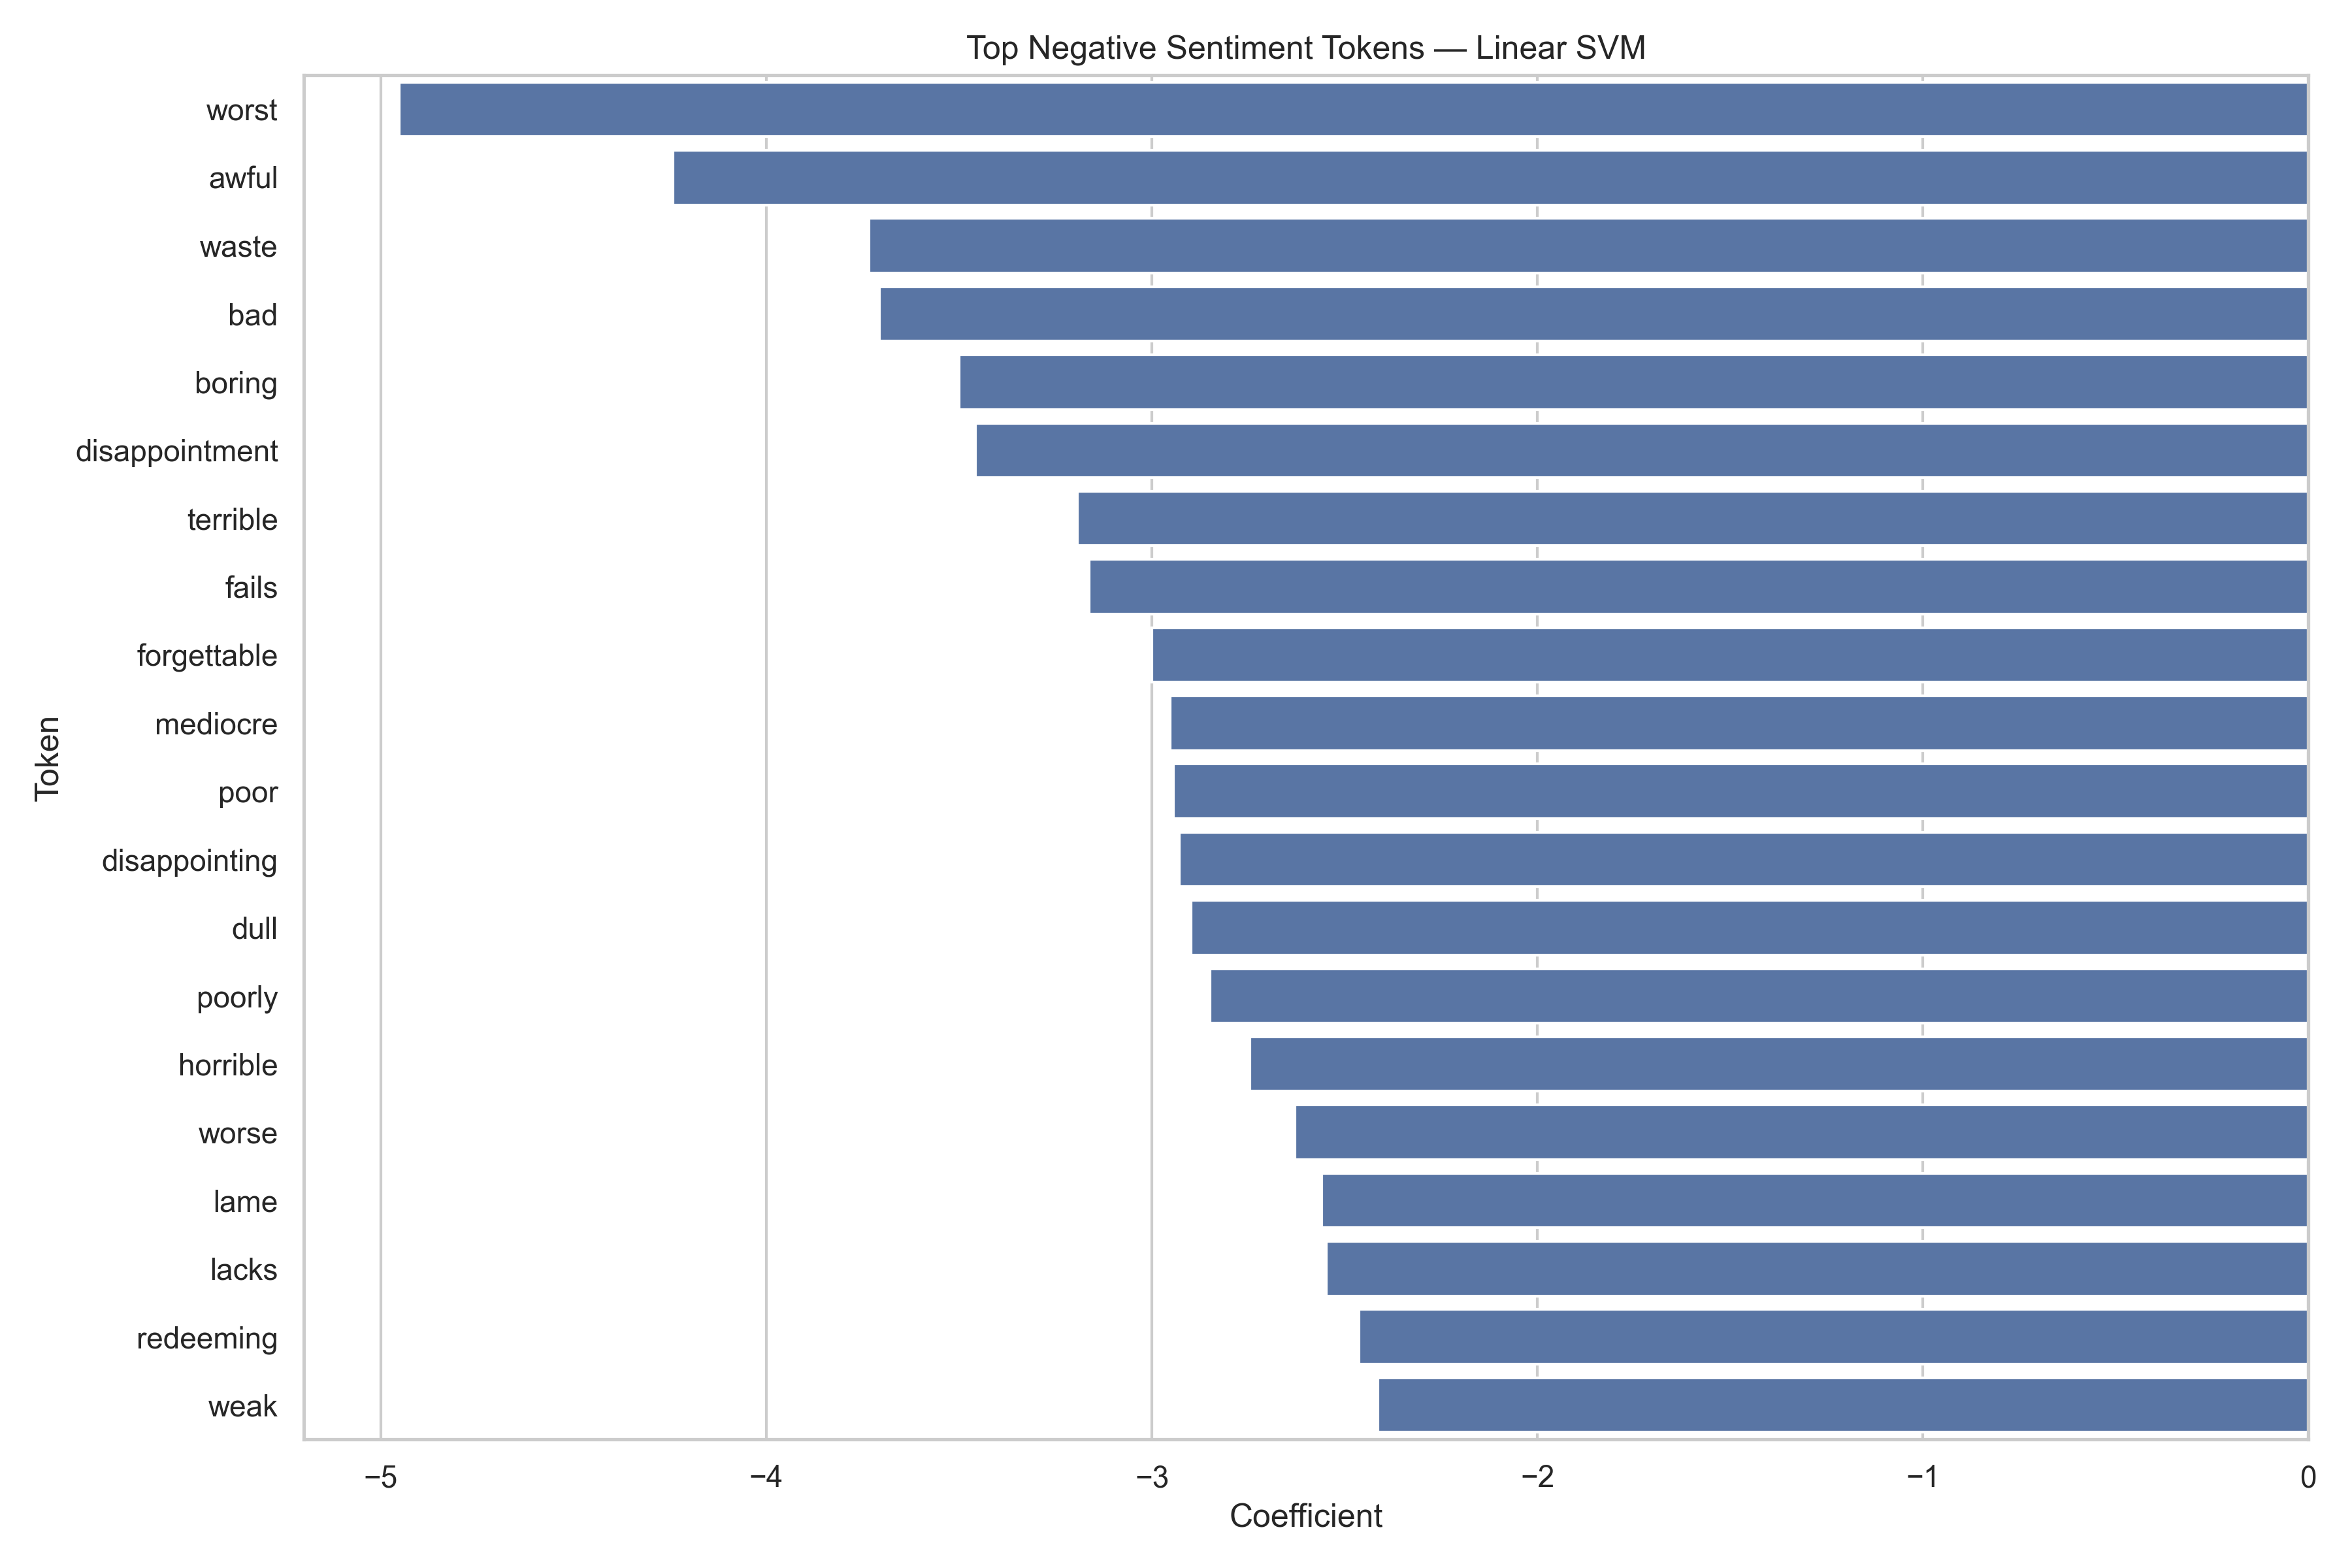

In [17]:
display(Image(filename=FIGURES_DIR / "top_negative_sentiment_tokens.png"))

## Negative Sentiment Signals

The strongest negative sentiment tokens include worst, awful, waste, bad, boring, disappointment, terrible, fails, forgettable, mediocre, poor, dull, and horrible.

Some tokens can be context-dependent. For example, a word like redeeming may appear negative because it often occurs in phrases such as "no redeeming qualities."

In [18]:
error_analysis["error_type"].value_counts()

error_type
correct           6694
false_positive     391
false_negative     353
Name: count, dtype: int64

In [19]:
error_rate_by_sentiment = (
    error_analysis
    .groupby("actual_sentiment")["is_error"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="error_rate_percent")
)

error_rate_by_sentiment

,actual_sentiment,error_rate_percent
0,negative,10.5500
1,positive,9.4600


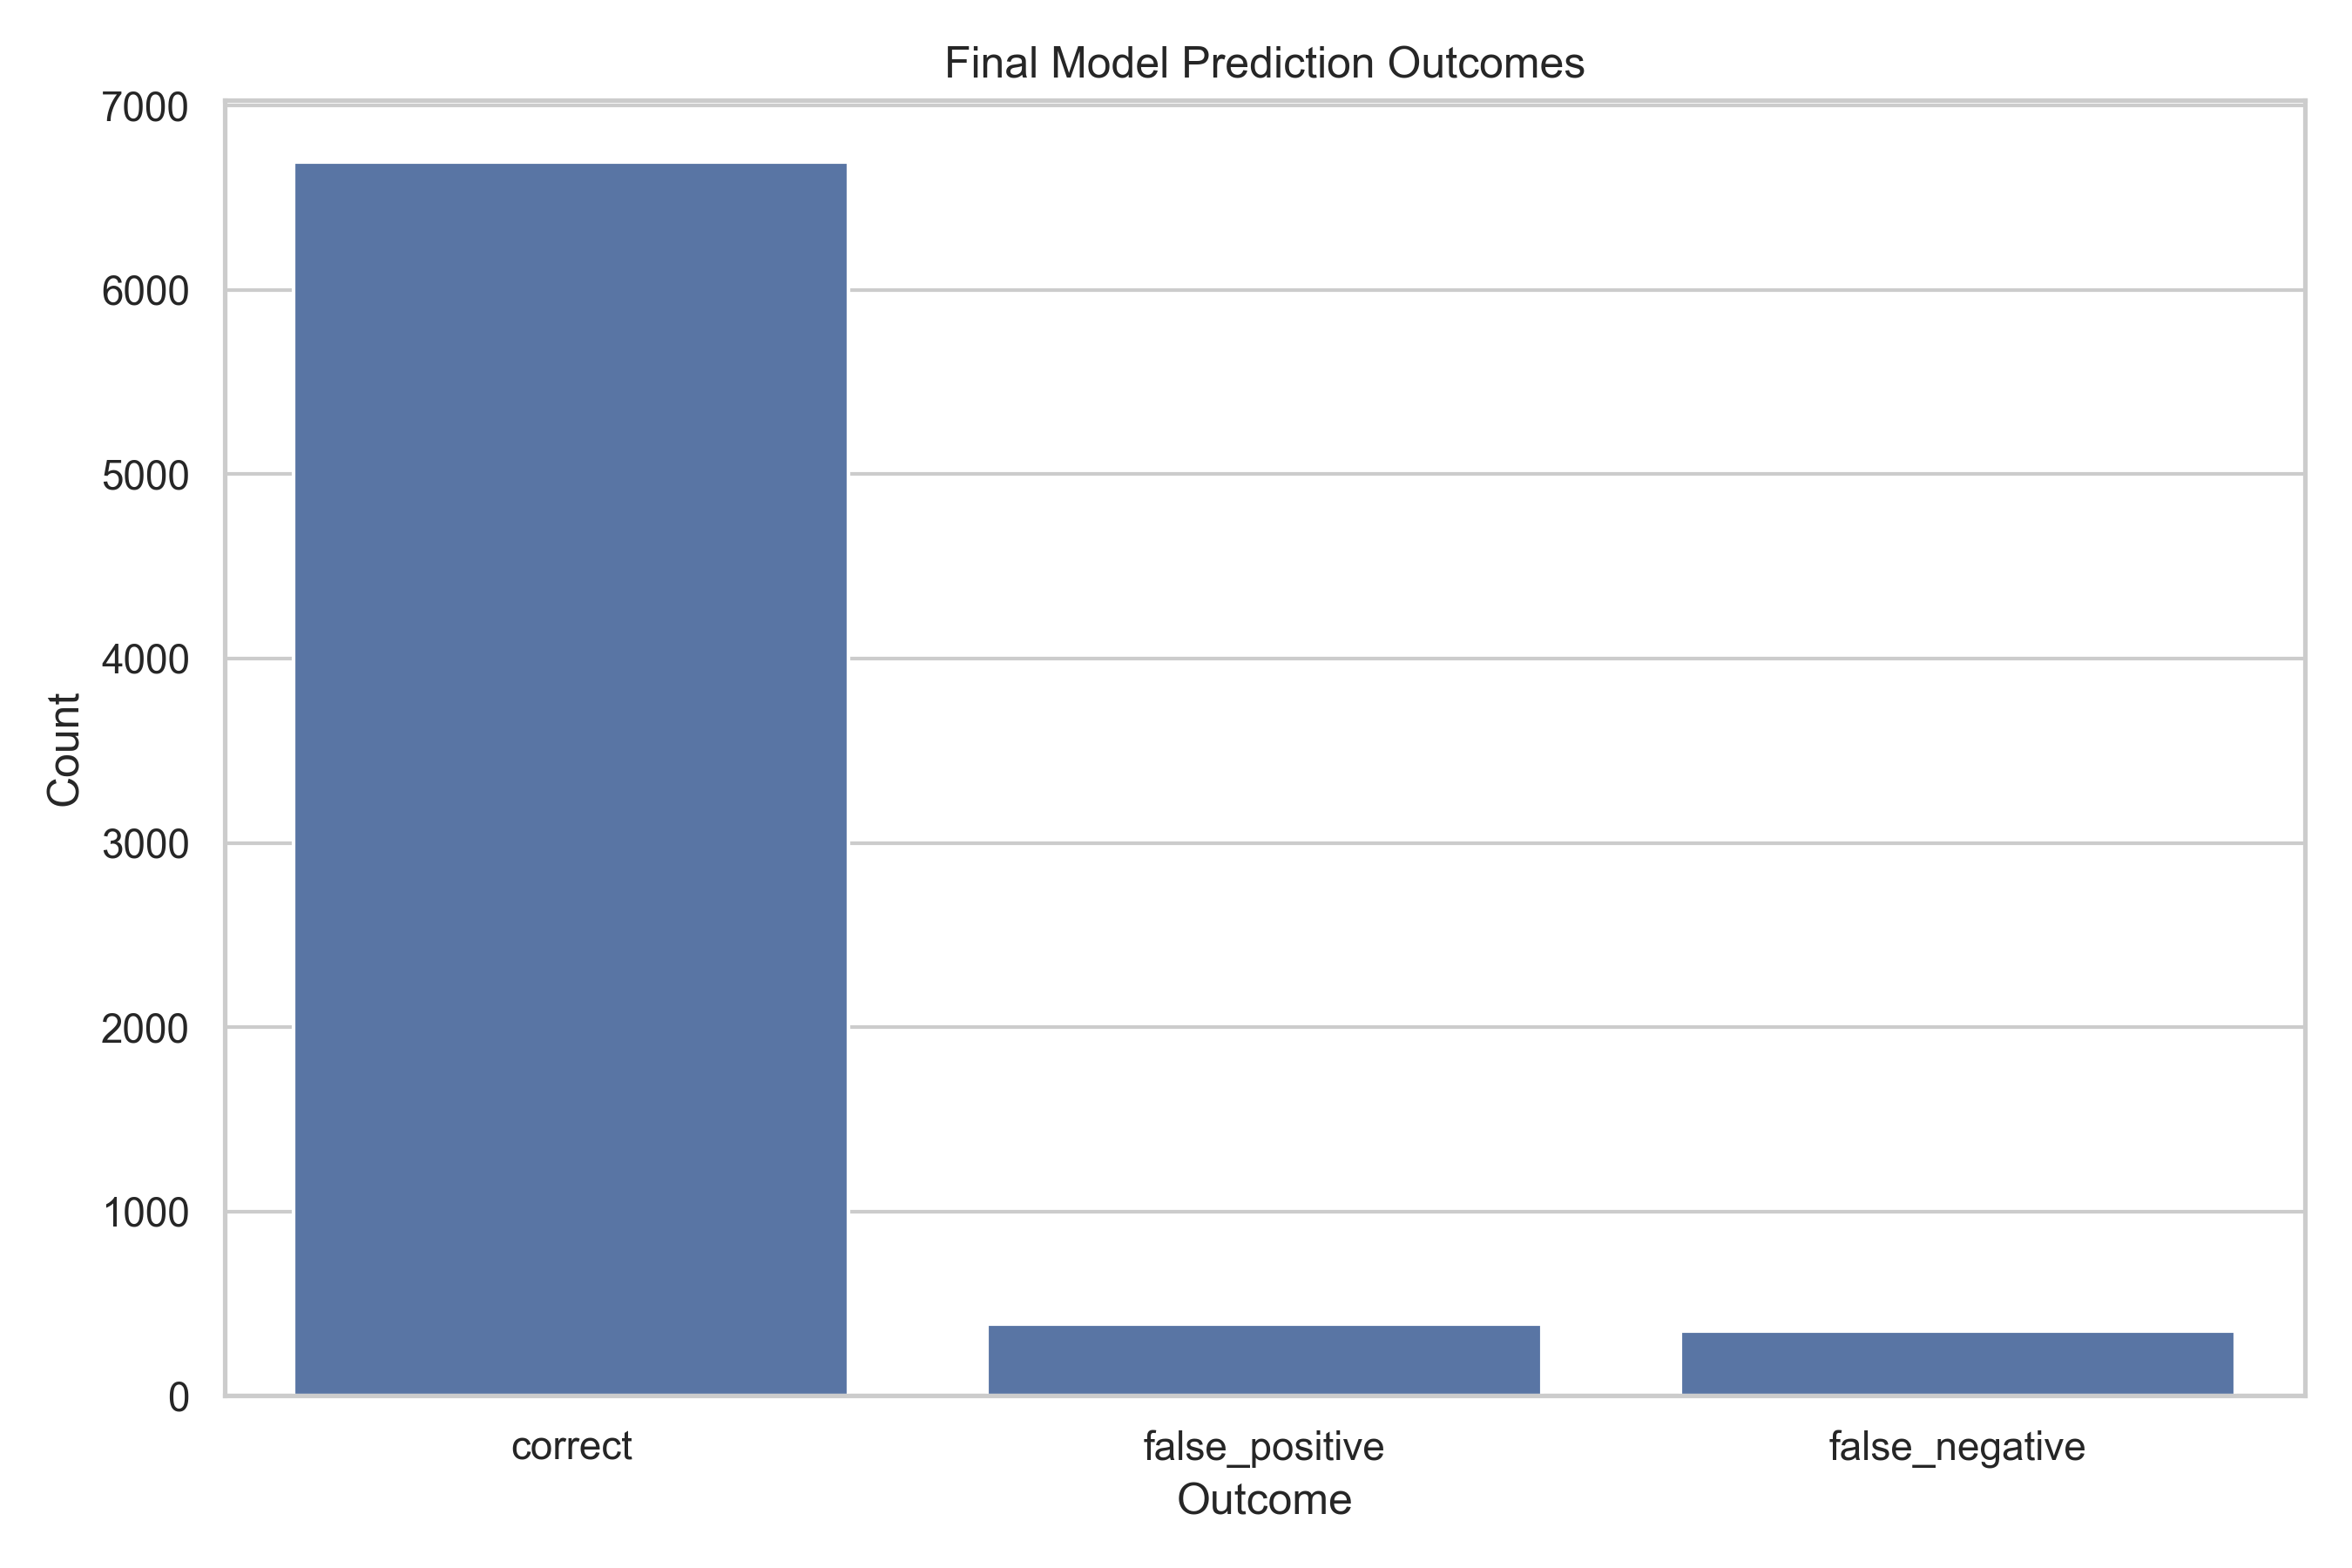

In [20]:
display(Image(filename=FIGURES_DIR / "prediction_outcomes.png"))

## Error Analysis

The final model produces 744 errors on the test set.

The error rate is slightly higher for negative reviews than for positive reviews.

This suggests the model is marginally more likely to classify some negative reviews as positive than the opposite, but the difference is not large.

In [21]:
error_analysis.groupby("is_error")["clean_word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
is_error,,,,,,,,
False,"6,694.0000",227.8606,169.8810,20.0000,125.0000,171.0000,273.0000,"2,240.0000"
True,744.0000,219.4530,160.4014,8.0000,122.0000,166.5000,276.0000,"1,008.0000"


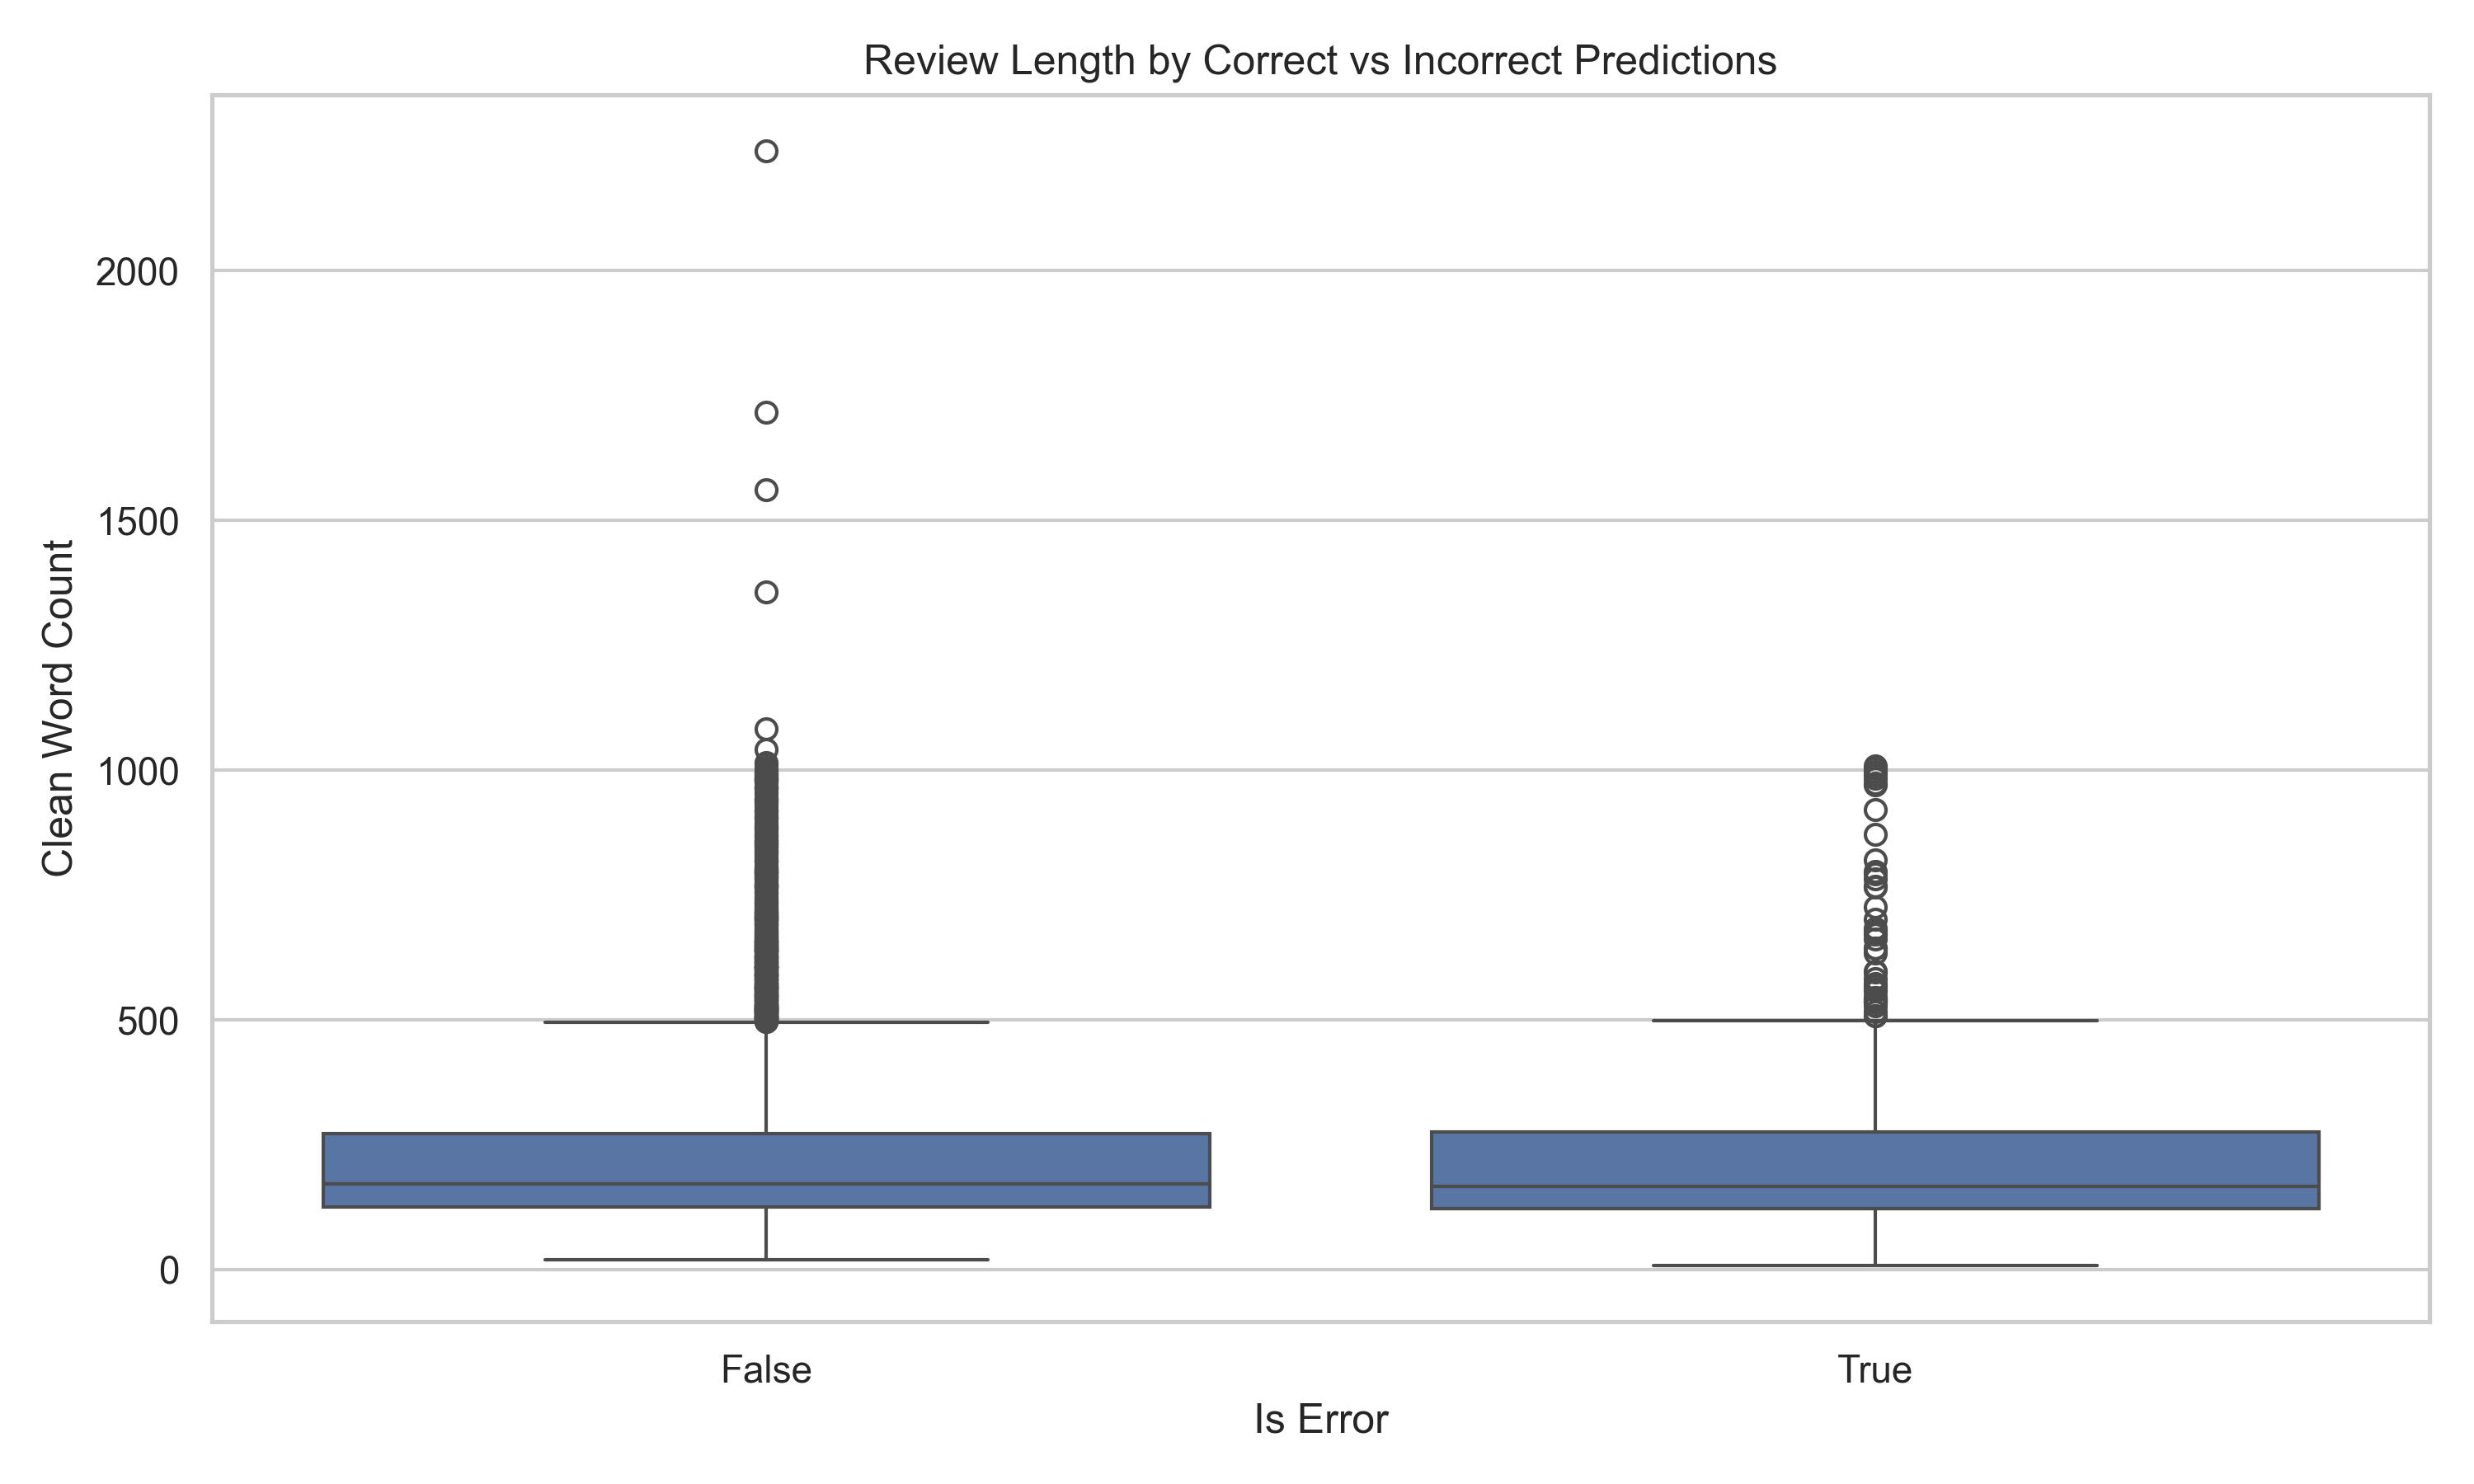

In [22]:
display(Image(filename=FIGURES_DIR / "review_length_by_error_status.png"))

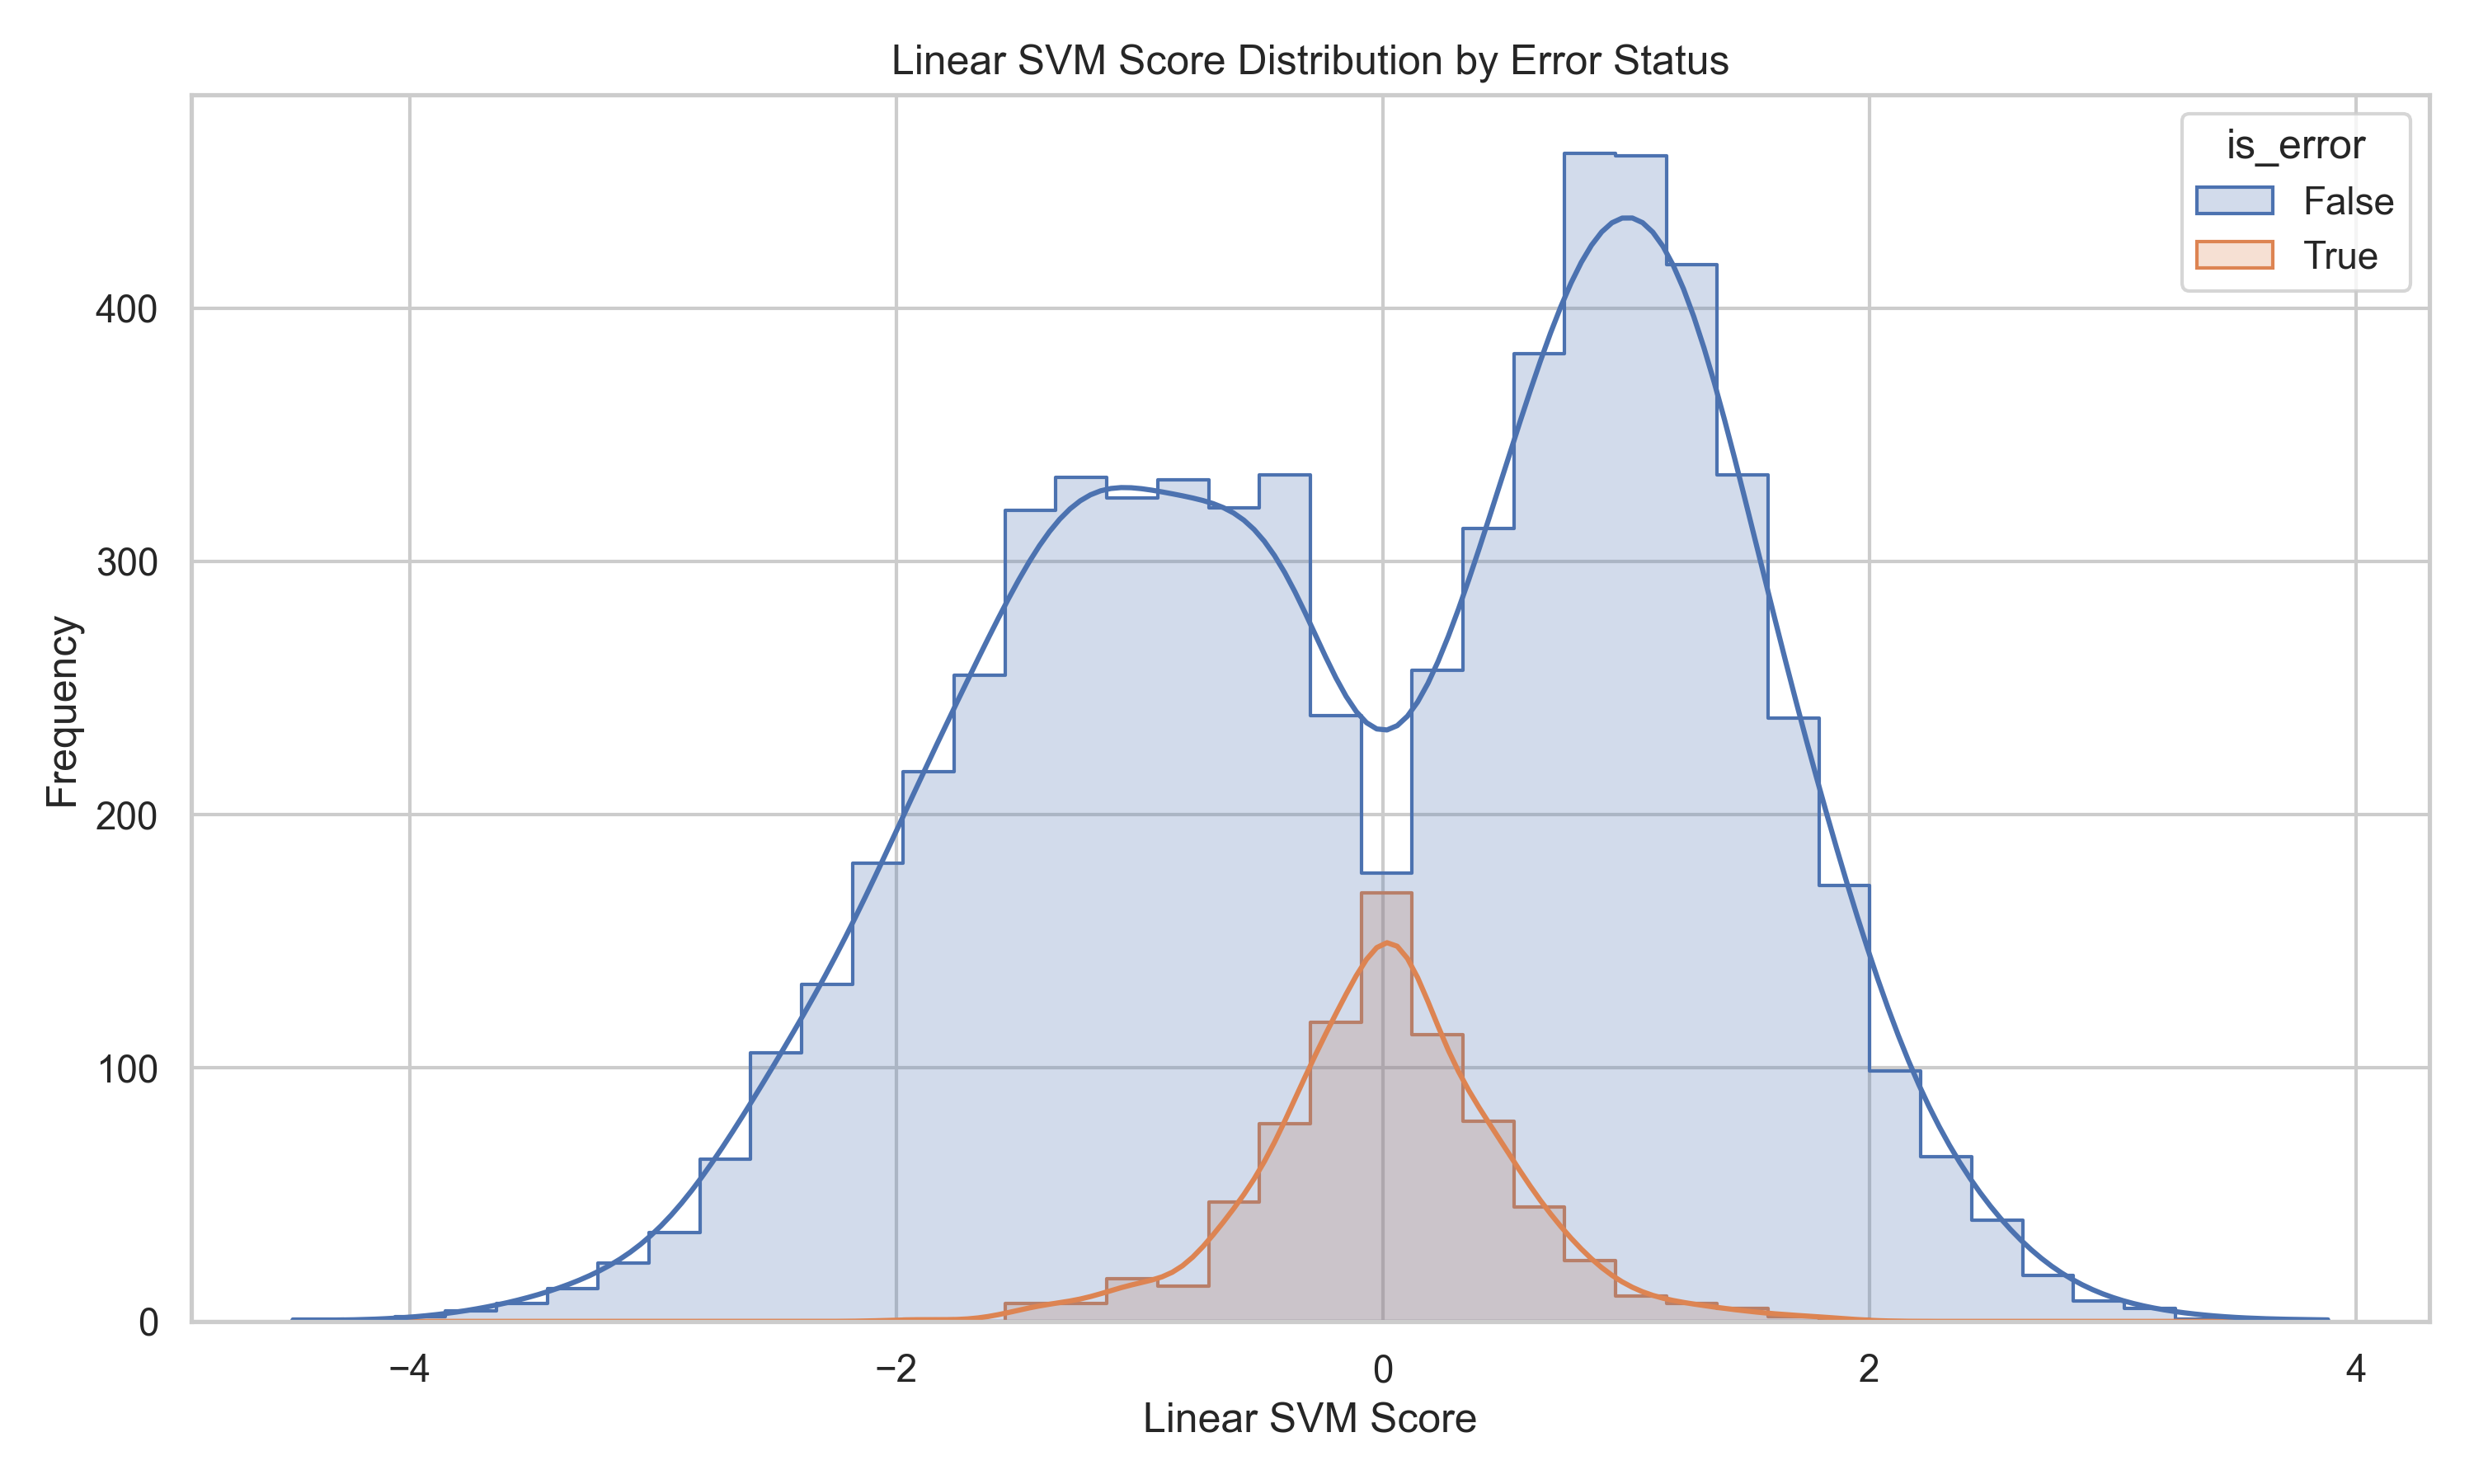

In [23]:
display(Image(filename=FIGURES_DIR / "score_distribution_by_error_status.png"))

## Error Patterns

Incorrect predictions are not simply caused by longer reviews.

The median word count of incorrect reviews is close to the median word count of correct reviews.

Errors are more likely when the model score is closer to the decision boundary. This is expected because low-margin examples often contain mixed sentiment, subtle language, negation, or ambiguous phrasing.

## Key Findings

- The dataset is balanced and suitable for binary sentiment classification.
- 418 duplicate reviews were removed before splitting to prevent leakage.
- TF-IDF with linear models performs strongly on movie review sentiment classification.
- Logistic Regression and Linear SVM are the strongest models.
- Cross-validation selected Linear SVM as the final model.
- The final Linear SVM model achieved approximately 0.90 F1-score on the held-out test set.
- The model achieved ROC-AUC and Average Precision above 0.96.
- Positive and negative token coefficients are interpretable and mostly align with intuitive sentiment language.
- The model still makes errors on ambiguous, mixed, or context-dependent reviews.

## Business Recommendations

- Use the model as a scalable sentiment monitoring tool, not as a perfect judge of opinion.
- Review low-confidence predictions manually if the decision is high impact.
- Use aggregate sentiment trends rather than relying only on individual predictions.
- Extend the model with domain-specific data before applying it outside movie reviews.
- Monitor errors involving sarcasm, negation, and mixed sentiment.

## Limitations

- The model is trained on movie reviews and may not generalize to other domains.
- TF-IDF does not deeply understand context, sarcasm, or complex negation.
- Linear coefficients are useful for interpretation, but they are not causal explanations.
- The model does not use modern contextual embeddings or transformers in this version.
- Raw review text is not stored in repository outputs to avoid unnecessary dataset redistribution.